# Heart 2020 (cleaned) — exploratory data study

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
cwd = Path.cwd().resolve()
if cwd.name == "research":
    csv_path = cwd.parent / "dataset" / "heart_2020_cleaned.csv"
else:
    csv_path = cwd / "dataset" / "heart_2020_cleaned.csv"

if not csv_path.is_file():
    raise FileNotFoundError(f"Expected CSV at: {csv_path}")

df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape (rows, cols):", df.shape)

Loaded: C:\Users\Aditya\Documents\Masters\DL NN\DeepLearningNeuralNetwork\finalproject\dataset\heart_2020_cleaned.csv
Shape (rows, cols): (319795, 18)


## Column names and dtypes

In [3]:
cols = list(df.columns)
print("Number of columns:", len(cols))
display(pd.DataFrame({"column": cols, "dtype": df.dtypes.astype(str).values}))

Number of columns: 18


,column,dtype
0,HeartDisease,object
1,BMI,float64
2,Smoking,object
3,AlcoholDrinking,object
4,Stroke,object
5,PhysicalHealth,int64
6,MentalHealth,int64
7,DiffWalking,object
8,Sex,object
9,AgeCategory,object


## Memory usage

In [4]:
mem_total = df.memory_usage(deep=True).sum()
mem_by_col = df.memory_usage(deep=True).sort_values(ascending=False)
print(f"Total deep memory: {mem_total / 1e6:.2f} MB")
display(mem_by_col.to_frame("bytes").assign(MB=lambda x: (x["bytes"] / 1e6).round(3)))

Total deep memory: 279.98 MB


,bytes,MB
GenHealth,20410995,20.411
Race,20039678,20.040
AgeCategory,19972208,19.972
Sex,19843105,19.843
PhysicalActivity,19115862,19.116
Diabetic,19102288,19.102
Smoking,18999813,19.000
DiffWalking,18912315,18.912
Asthma,18910777,18.911
SkinCancer,18897724,18.898


## First / last rows and random sample

In [5]:
display(df.head(10))

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No
5,Yes,28.87,Yes,No,No,6,0,Yes,Female,75-79,Black,No,No,Fair,12,No,No,No
6,No,21.63,No,No,No,15,0,No,Female,70-74,White,No,Yes,Fair,4,Yes,No,Yes
7,No,31.64,Yes,No,No,5,0,Yes,Female,80 or older,White,Yes,No,Good,9,Yes,No,No
8,No,26.45,No,No,No,0,0,No,Female,80 or older,White,"No, borderline diabetes",No,Fair,5,No,Yes,No
9,No,40.69,No,No,No,0,0,Yes,Male,65-69,White,No,Yes,Good,10,No,No,No


In [6]:
display(df.tail(10))

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
319785,No,31.93,No,Yes,No,0,0,No,Male,65-69,Hispanic,No,Yes,Good,7,No,No,No
319786,Yes,33.20,Yes,No,No,0,0,No,Female,60-64,Hispanic,Yes,Yes,Very good,8,Yes,No,No
319787,No,36.54,No,No,No,7,0,No,Male,30-34,Hispanic,No,No,Good,9,No,No,No
319788,No,23.38,No,No,No,0,0,No,Female,60-64,Hispanic,No,Yes,Excellent,6,No,No,No
319789,No,22.22,No,No,No,0,0,No,Female,18-24,Hispanic,No,Yes,Excellent,8,No,No,No
319790,Yes,27.41,Yes,No,No,7,0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6,Yes,No,No
319791,No,29.84,Yes,No,No,0,0,No,Male,35-39,Hispanic,No,Yes,Very good,5,Yes,No,No
319792,No,24.24,No,No,No,0,0,No,Female,45-49,Hispanic,No,Yes,Good,6,No,No,No
319793,No,32.81,No,No,No,0,0,No,Female,25-29,Hispanic,No,No,Good,12,No,No,No
319794,No,46.56,No,No,No,0,0,No,Female,80 or older,Hispanic,No,Yes,Good,8,No,No,No


In [7]:
display(df.sample(10, random_state=RANDOM_STATE))

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
271884,No,27.63,Yes,No,No,0,25,No,Female,25-29,Hispanic,No,Yes,Very good,7,No,No,No
270361,No,21.95,No,No,No,0,20,No,Female,30-34,White,No,Yes,Excellent,6,No,No,Yes
219060,No,31.32,Yes,No,No,0,0,No,Female,40-44,White,No,Yes,Very good,6,Yes,No,No
24010,No,40.35,No,No,No,30,0,No,Female,65-69,White,No,No,Good,8,No,No,No
181930,No,35.61,Yes,No,No,30,30,Yes,Female,60-64,White,No,No,Fair,4,Yes,No,Yes
24149,Yes,24.63,Yes,No,No,0,0,No,Female,80 or older,White,Yes,Yes,Very good,8,No,No,No
185683,No,41.73,No,No,No,0,0,No,Male,35-39,White,No,Yes,Very good,7,No,No,No
316656,No,16.30,No,No,No,2,0,No,Female,25-29,Hispanic,No,No,Excellent,8,No,No,No
305719,No,21.52,Yes,No,No,30,0,No,Male,65-69,White,No,No,Good,8,No,No,No
56786,No,29.53,Yes,No,No,28,30,Yes,Male,45-49,Black,No,Yes,Fair,5,Yes,No,No


## `info()` — non-null counts and dtypes

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  int64  
 6   MentalHealth      319795 non-null  int64  
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  int64  
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

## `describe()` — all columns (numeric + categorical summary)

In [9]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
HeartDisease,319795,2,No,292422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,319795.0,NaN,NaN,NaN,28.325399,6.3561,12.02,24.03,27.34,31.42,94.85
Smoking,319795,2,No,187887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AlcoholDrinking,319795,2,No,298018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stroke,319795,2,No,307726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhysicalHealth,319795.0,NaN,NaN,NaN,3.37171,7.95085,0.0,0.0,0.0,2.0,30.0
MentalHealth,319795.0,NaN,NaN,NaN,3.898366,7.955235,0.0,0.0,0.0,3.0,30.0
DiffWalking,319795,2,No,275385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,319795,2,Female,167805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AgeCategory,319795,13,65-69,34151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Numeric-only `describe()`

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)
display(df[num_cols].describe().T)

Numeric columns: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']


,count,mean,std,min,25%,50%,75%,max
BMI,319795.0,28.325399,6.356100,12.02,24.03,27.34,31.42,94.85
PhysicalHealth,319795.0,3.371710,7.950850,0.00,0.00,0.00,2.00,30.00
MentalHealth,319795.0,3.898366,7.955235,0.00,0.00,0.00,3.00,30.00
SleepTime,319795.0,7.097075,1.436007,1.00,6.00,7.00,8.00,24.00


## Object / category columns — top values

In [11]:
obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in obj_cols:
    print(f"\n=== {c} ===")
    display(df[c].value_counts(dropna=False))


=== HeartDisease ===


HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64


=== Smoking ===


Smoking
No     187887
Yes    131908
Name: count, dtype: int64


=== AlcoholDrinking ===


...

Asthma
No     276923
Yes     42872
Name: count, dtype: int64


=== KidneyDisease ===


KidneyDisease
No     308016
Yes     11779
Name: count, dtype: int64


=== SkinCancer ===


SkinCancer
No     289976
Yes     29819
Name: count, dtype: int64

## Missing values per column

In [12]:
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(4)
miss_tbl = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
display(miss_tbl[miss_tbl["missing_count"] > 0])
if miss_tbl["missing_count"].max() == 0:
    print("No missing values in any column.")

,missing_count,missing_pct


No missing values in any column.


## Duplicate rows

In [13]:
dup_full = df.duplicated().sum()
print(f"Fully duplicate rows: {dup_full} ({100 * dup_full / len(df):.4f}%)")
if dup_full:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(20))

Fully duplicate rows: 18078 (5.6530%)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
186950,No,15.43,No,No,No,0,0,Yes,Male,35-39,American Indian/Alaskan Native,No,Yes,Good,8,Yes,No,No
187048,No,15.43,No,No,No,0,0,Yes,Male,35-39,American Indian/Alaskan Native,No,Yes,Good,8,Yes,No,No
188282,No,15.43,No,No,No,0,0,Yes,Male,35-39,American Indian/Alaskan Native,No,Yes,Good,8,Yes,No,No
188328,No,15.43,No,No,No,0,0,Yes,Male,35-39,American Indian/Alaskan Native,No,Yes,Good,8,Yes,No,No
75493,No,16.24,Yes,No,No,2,10,No,Male,18-24,White,No,Yes,Good,5,No,No,No
104851,No,16.24,Yes,No,No,2,10,No,Male,18-24,White,No,Yes,Good,5,No,No,No
20332,No,16.64,No,No,No,0,0,No,Female,80 or older,White,No,Yes,Very good,8,No,No,No
230319,No,16.64,No,No,No,0,0,No,Female,80 or older,White,No,Yes,Very good,8,No,No,No
154193,No,16.82,Yes,No,No,0,0,No,Female,65-69,White,No,No,Good,6,No,No,No
168816,No,16.82,Yes,No,No,0,0,No,Female,65-69,White,No,No,Good,6,No,No,No


## Cardinality: unique values per column

In [14]:
card = pd.DataFrame({
    "n_unique": df.nunique(dropna=False),
    "dtype": df.dtypes.astype(str),
}).sort_values("n_unique", ascending=False)
display(card)

,n_unique,dtype
BMI,3604,float64
PhysicalHealth,31,int64
MentalHealth,31,int64
SleepTime,24,int64
AgeCategory,13,object
Race,6,object
GenHealth,5,object
Diabetic,4,object
KidneyDisease,2,object
Asthma,2,object


## Target: `HeartDisease` — counts and rates

In [15]:
vc = df["HeartDisease"].value_counts(dropna=False)
vc_pct = df["HeartDisease"].value_counts(normalize=True, dropna=False).mul(100).round(3)
tgt_tbl = pd.DataFrame({"count": vc, "pct": vc_pct})
display(tgt_tbl)
print("Class imbalance ratio (majority/minority):", vc.max() / vc.min())

,count,pct
HeartDisease,,
No,292422,91.44
Yes,27373,8.56


Class imbalance ratio (majority/minority): 10.682862674898622


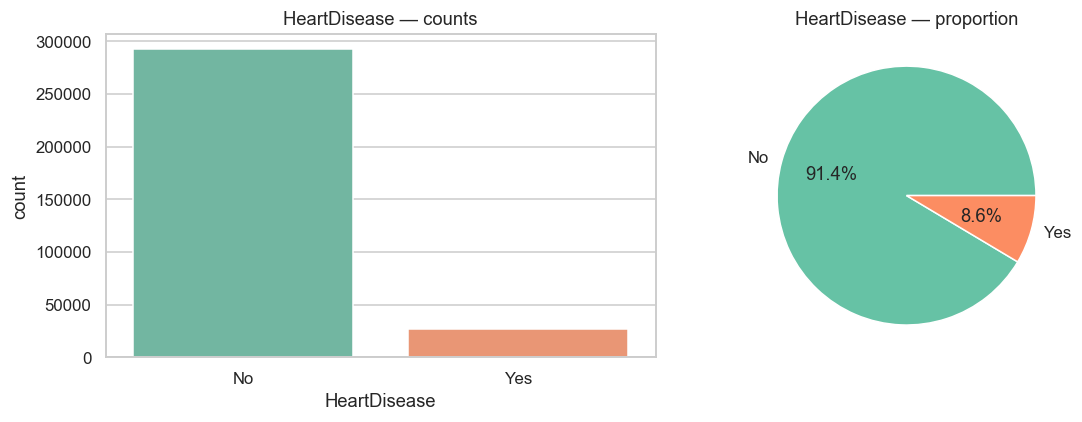

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="HeartDisease", order=vc.index, ax=axes[0], palette="Set2")
axes[0].set_title("HeartDisease — counts")
axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%", colors=sns.color_palette("Set2", len(vc)))
axes[1].set_title("HeartDisease — proportion")
plt.tight_layout()
plt.show()

## Numeric features — histograms

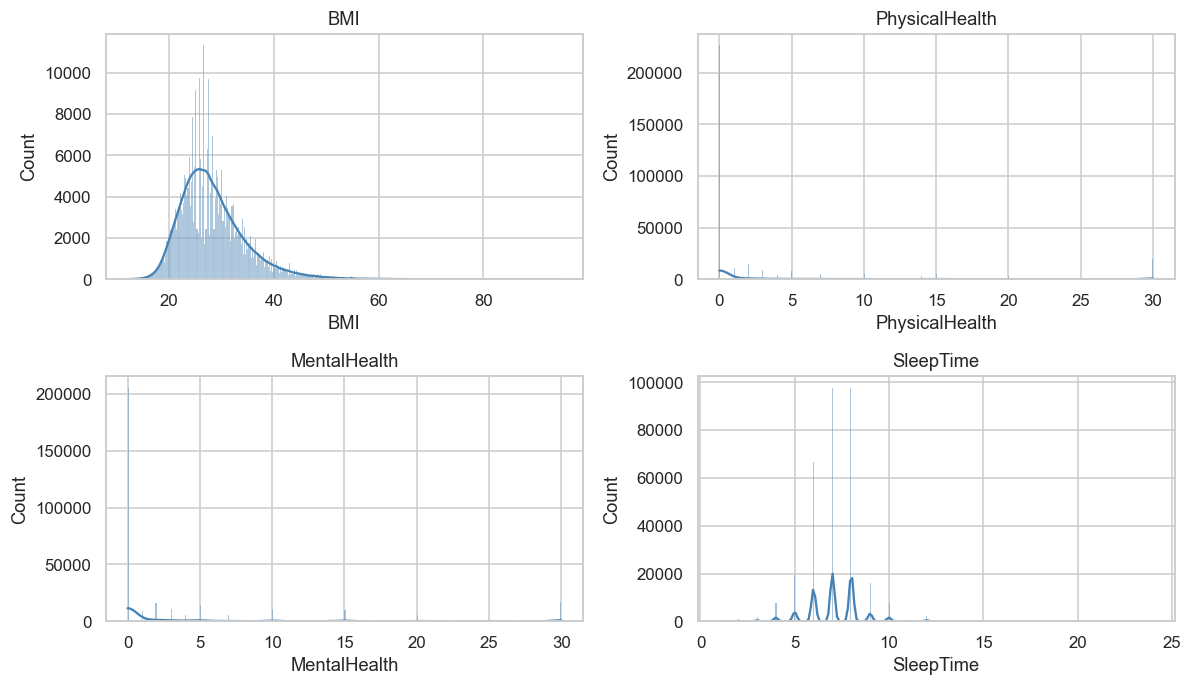

In [17]:
n = len(num_cols)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows))
axes = np.atleast_2d(axes).ravel()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## Numeric features — boxplots by `HeartDisease`

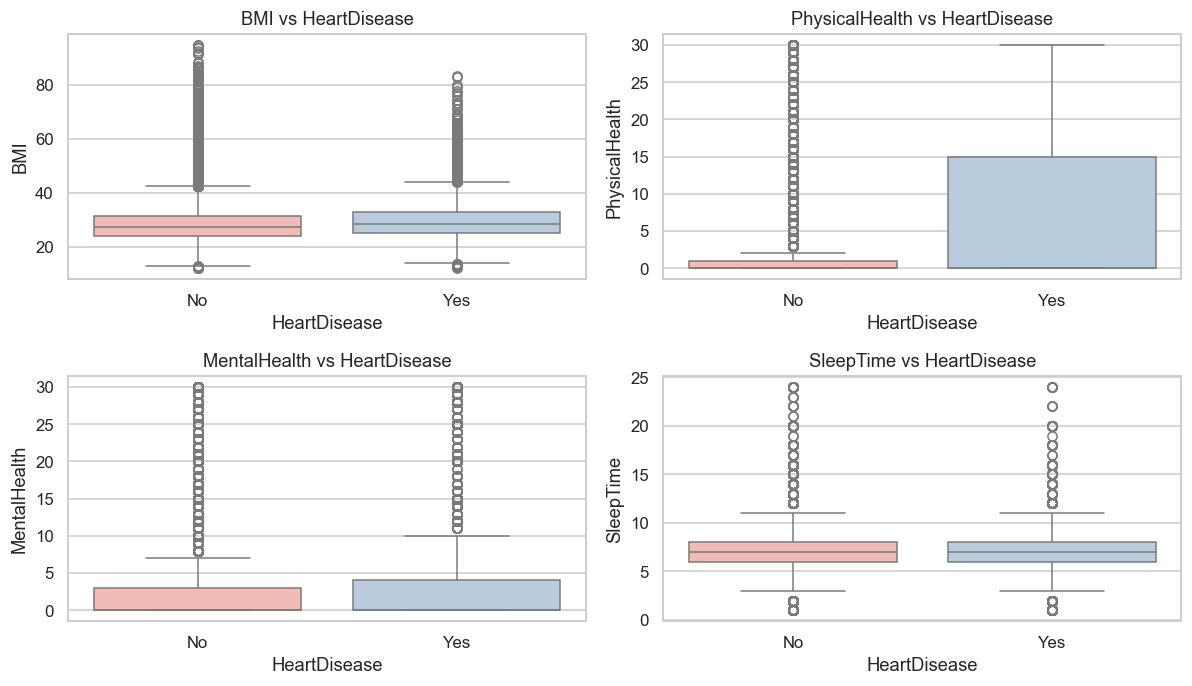

In [18]:
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows))
axes = np.atleast_2d(axes).ravel()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="HeartDisease", y=col, ax=axes[i], palette="Pastel1")
    axes[i].set_title(f"{col} vs HeartDisease")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## Violin plots (density + box) for numeric vs target

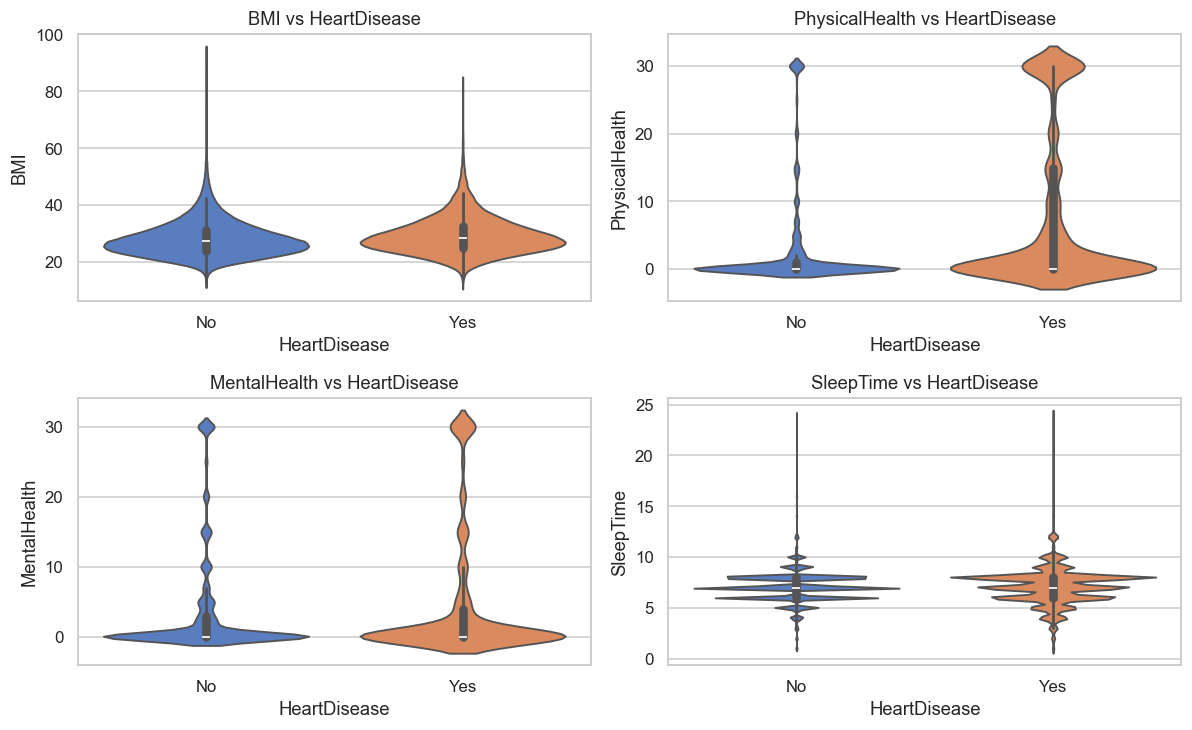

In [19]:
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.4 * nrows))
axes = np.atleast_2d(axes).ravel()
for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x="HeartDisease", y=col, ax=axes[i], palette="muted", inner="box")
    axes[i].set_title(f"{col} vs HeartDisease")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## Numeric skewness and kurtosis

,skewness,kurtosis
BMI,1.3324,3.8900
PhysicalHealth,2.6040,5.5284
MentalHealth,2.3311,4.4039
SleepTime,0.6790,7.8549


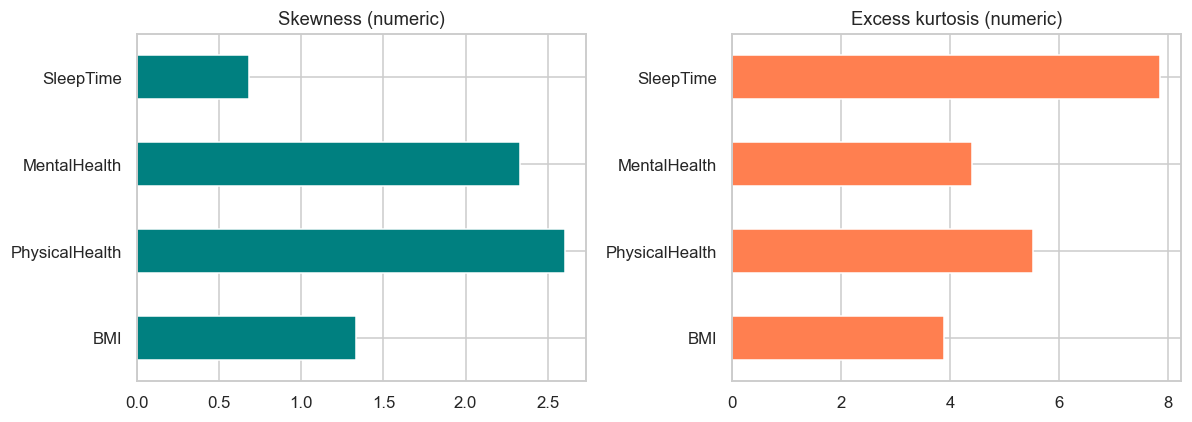

In [20]:
skew_kurt = pd.DataFrame({
    "skewness": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurtosis(),
})
display(skew_kurt.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
skew_kurt["skewness"].plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Skewness (numeric)")
skew_kurt["kurtosis"].plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Excess kurtosis (numeric)")
plt.tight_layout()
plt.show()

## IQR-based potential outliers (numeric)

In [21]:
out_rows = []
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lo) | (df[col] > hi)
    out_rows.append({"column": col, "n_outside_iqr": int(mask.sum()), "pct": round(100 * mask.mean(), 3), "lower_fence": lo, "upper_fence": hi})
out_tbl = pd.DataFrame(out_rows)
display(out_tbl)

,column,n_outside_iqr,pct,lower_fence,upper_fence
0,BMI,10396,3.251,12.945,42.505
1,PhysicalHealth,47146,14.743,-3.000,5.000
2,MentalHealth,51576,16.128,-4.500,7.500
3,SleepTime,4543,1.421,3.000,11.000


## Correlation matrix (Pearson) — numeric columns only

,BMI,PhysicalHealth,MentalHealth,SleepTime
BMI,1.0000,0.1098,0.0641,-0.0518
PhysicalHealth,0.1098,1.0000,0.2880,-0.0614
MentalHealth,0.0641,0.2880,1.0000,-0.1197
SleepTime,-0.0518,-0.0614,-0.1197,1.0000


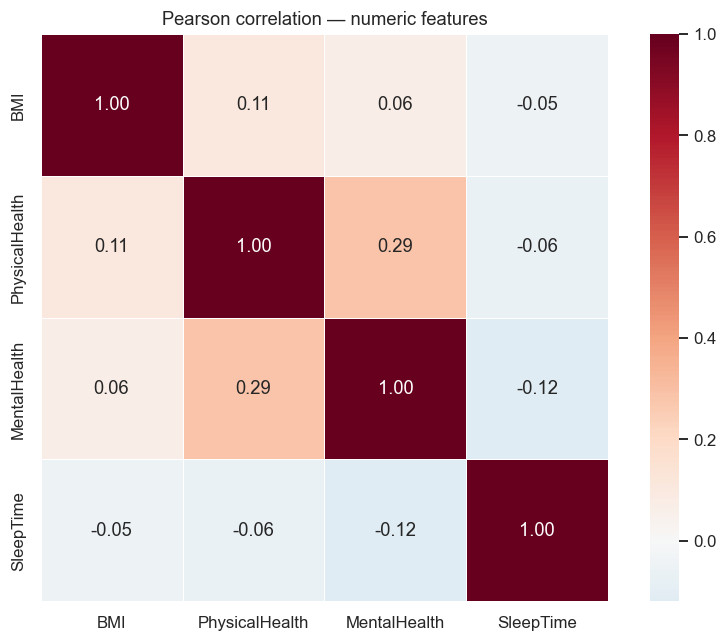

In [22]:
corr = df[num_cols].corr(method="pearson")
display(corr.round(4))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title("Pearson correlation — numeric features")
plt.tight_layout()
plt.show()

## Pairplot on numeric features (sampled for speed)

c:\Users\Aditya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


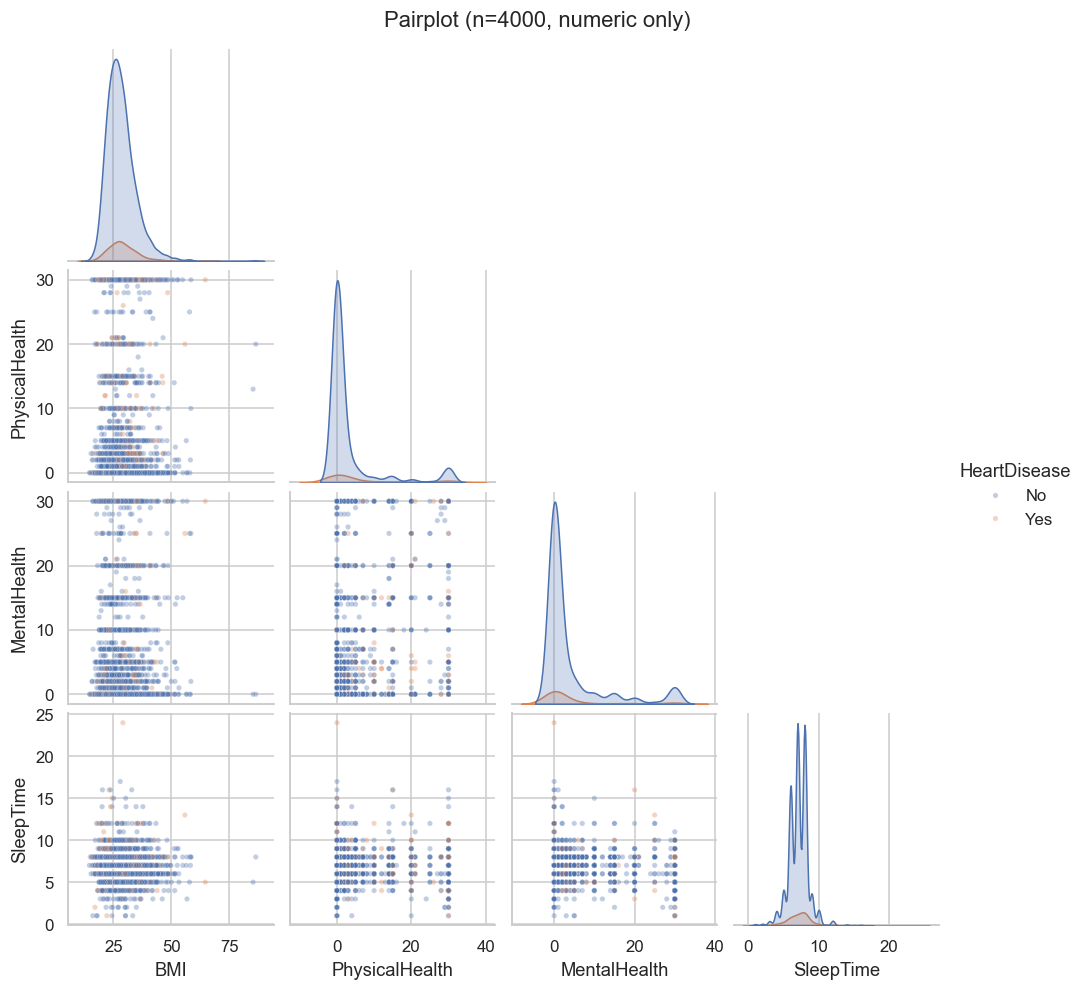

In [23]:
sample_n = min(4000, len(df))
pair_df = df[num_cols + ["HeartDisease"]].sample(sample_n, random_state=RANDOM_STATE)
g = sns.pairplot(pair_df, hue="HeartDisease", corner=True, plot_kws={"alpha": 0.35, "s": 12}, height=2.2)
g.fig.suptitle(f"Pairplot (n={sample_n}, numeric only)", y=1.02)
plt.show()

## Binary Yes/No columns — prevalence

Yes/No columns: ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']


,feature,Yes_pct
4,PhysicalActivity,77.54
0,Smoking,41.25
3,DiffWalking,13.89
5,Asthma,13.41
7,SkinCancer,9.32
1,AlcoholDrinking,6.81
2,Stroke,3.77
6,KidneyDisease,3.68


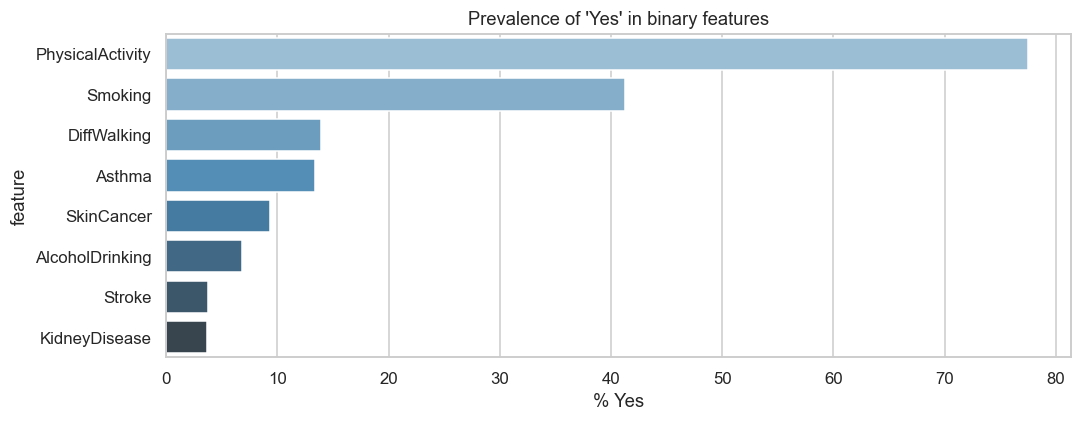

In [24]:
yn_cols = [c for c in df.columns if c != "HeartDisease" and set(df[c].dropna().unique()) <= {"Yes", "No"}]
print("Yes/No columns:", yn_cols)
prev = []
for c in yn_cols:
    prev.append({"feature": c, "Yes_pct": (df[c] == "Yes").mean() * 100})
prev_tbl = pd.DataFrame(prev).sort_values("Yes_pct", ascending=False)
display(prev_tbl.round(2))

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(yn_cols))))
sns.barplot(data=prev_tbl, y="feature", x="Yes_pct", ax=ax, palette="Blues_d")
ax.set_xlabel("% Yes")
ax.set_title("Prevalence of 'Yes' in binary features")
plt.tight_layout()
plt.show()

## Categorical features — count plots (one figure per column)

Categorical (non-numeric) columns: ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']


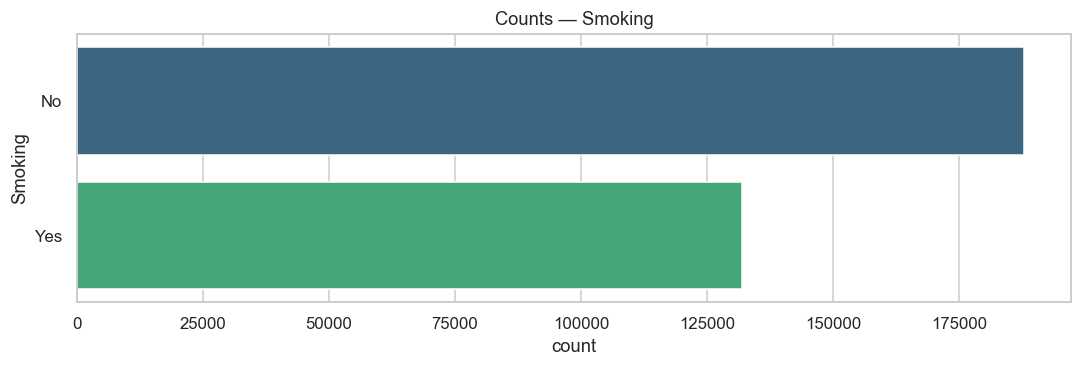

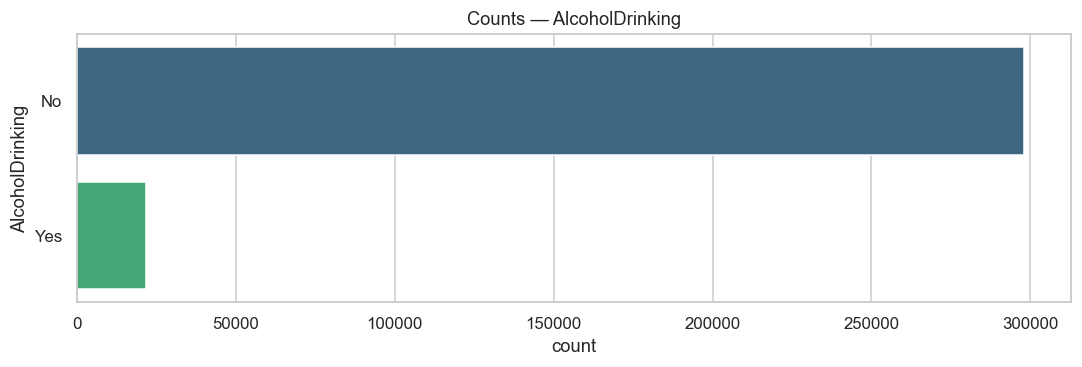

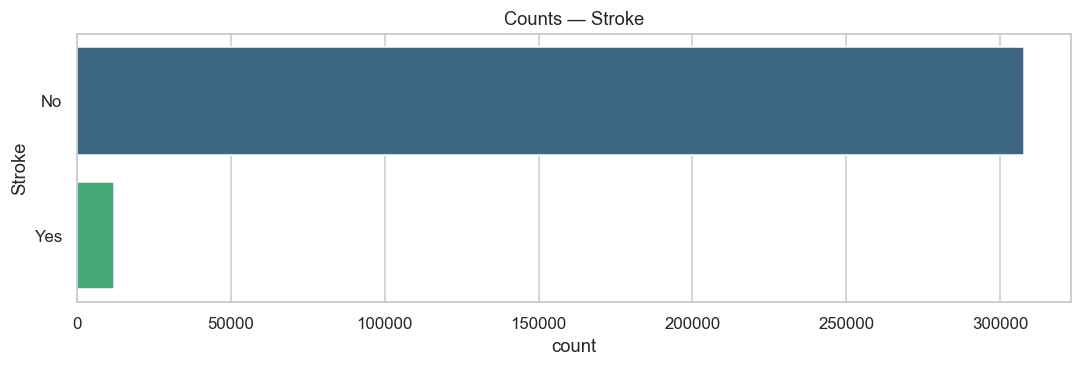

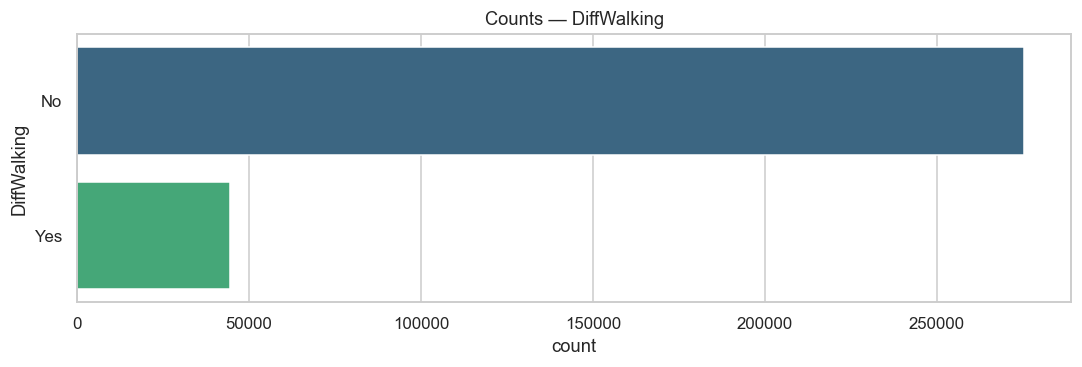

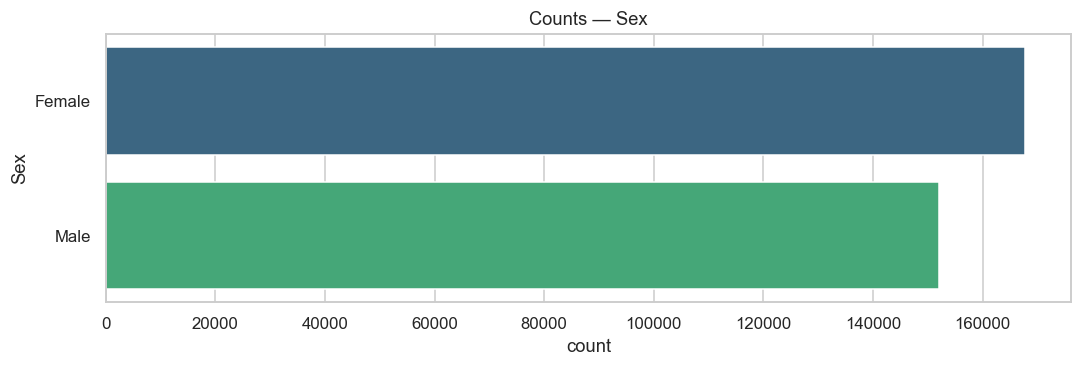

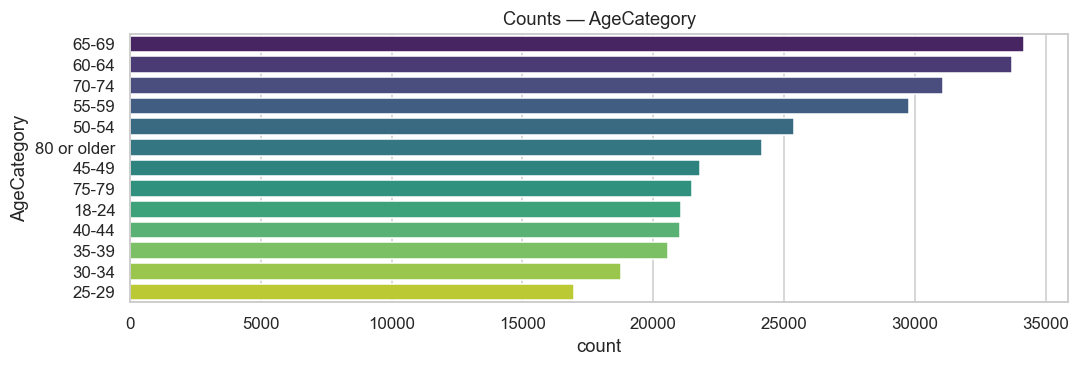

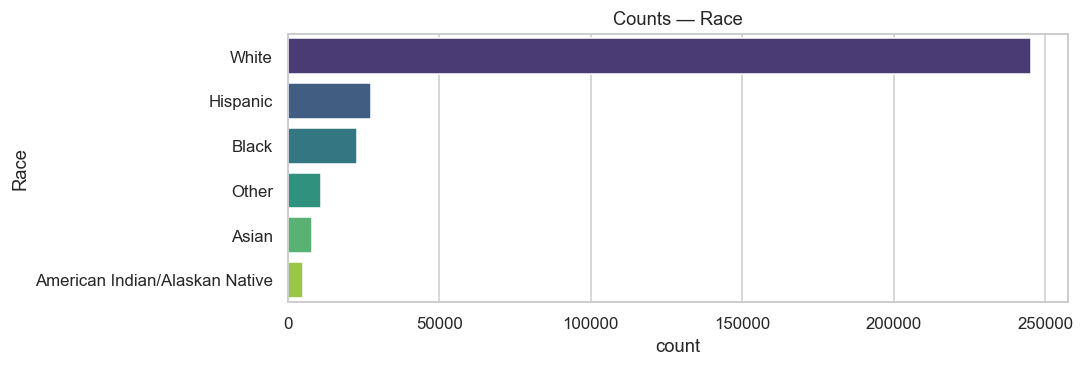

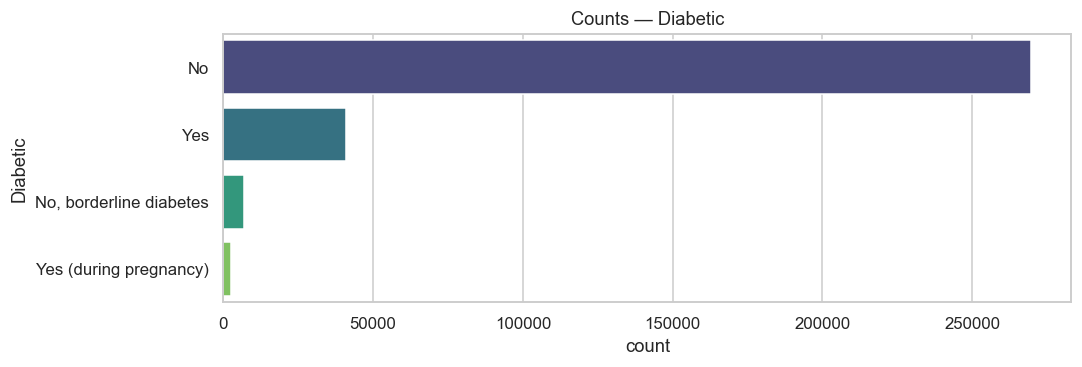

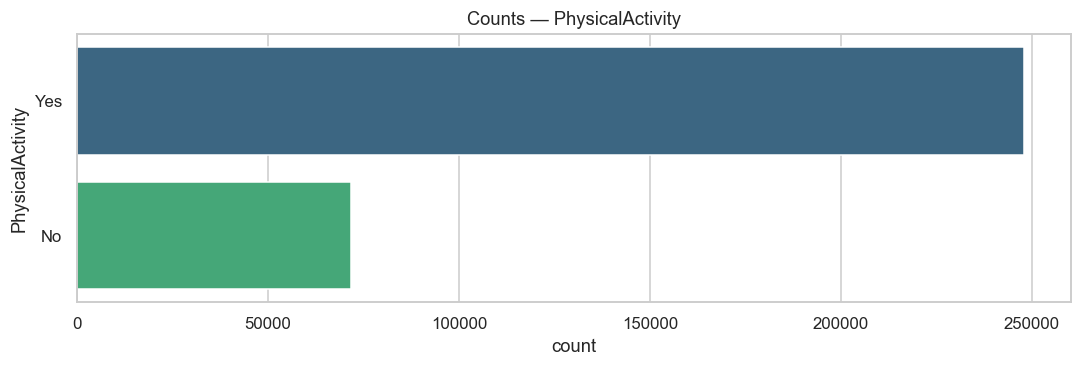

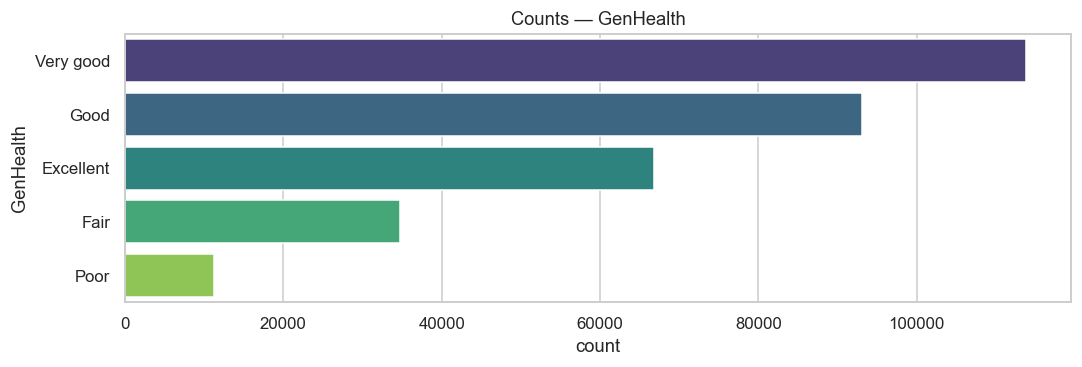

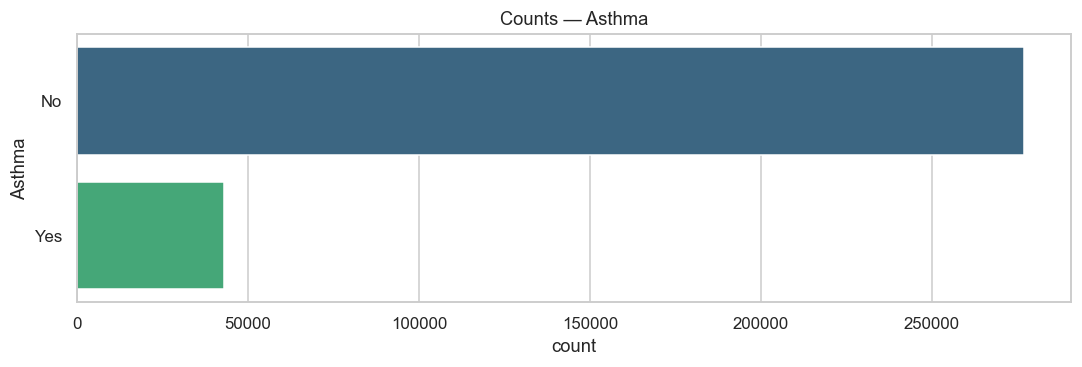

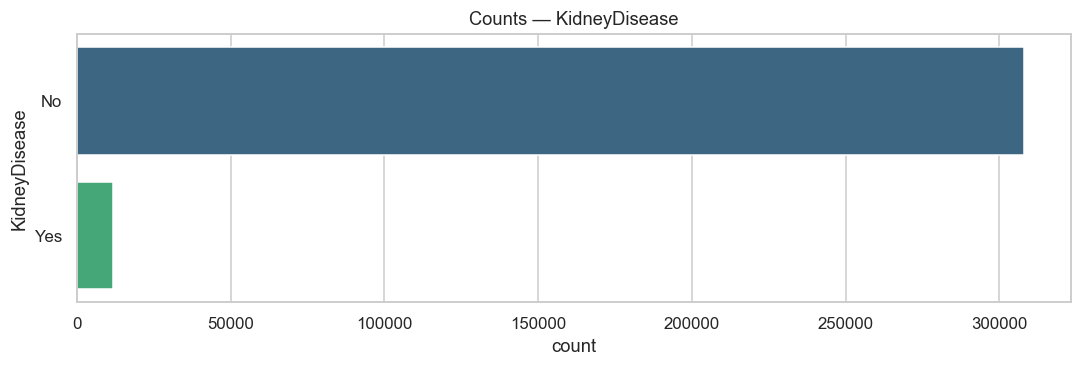

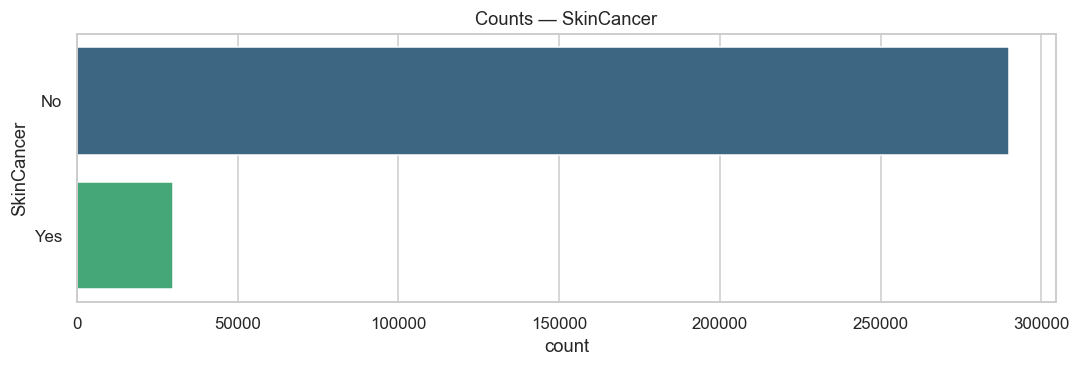

In [25]:
cat_cols = [c for c in df.columns if c not in num_cols and c != "HeartDisease"]
print("Categorical (non-numeric) columns:", cat_cols)

for col in cat_cols:
    order = df[col].value_counts().index.tolist()
    plt.figure(figsize=(10, max(3.5, 0.25 * len(order))))
    sns.countplot(data=df, y=col, order=order, palette="viridis")
    plt.title(f"Counts — {col}")
    plt.tight_layout()
    plt.show()

## `HeartDisease` rate (%) by each categorical level

,Smoking,heart_disease_pct
1,Yes,12.16
0,No,6.03


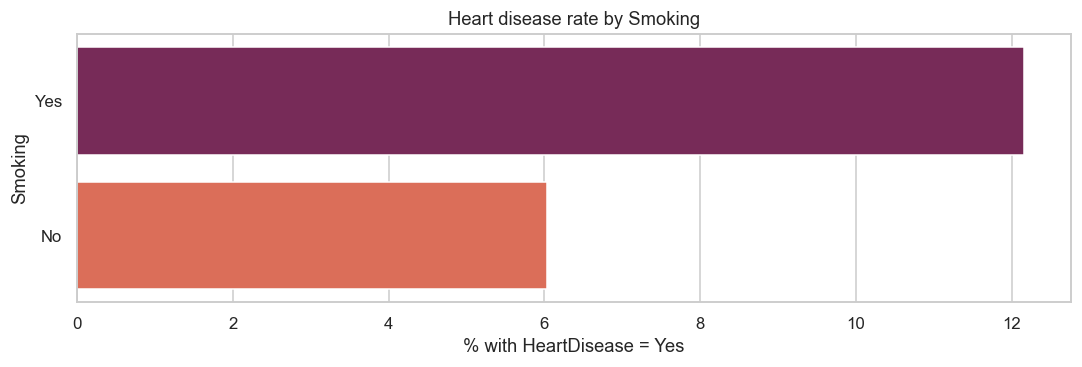

,AlcoholDrinking,heart_disease_pct
0,No,8.80
1,Yes,5.24


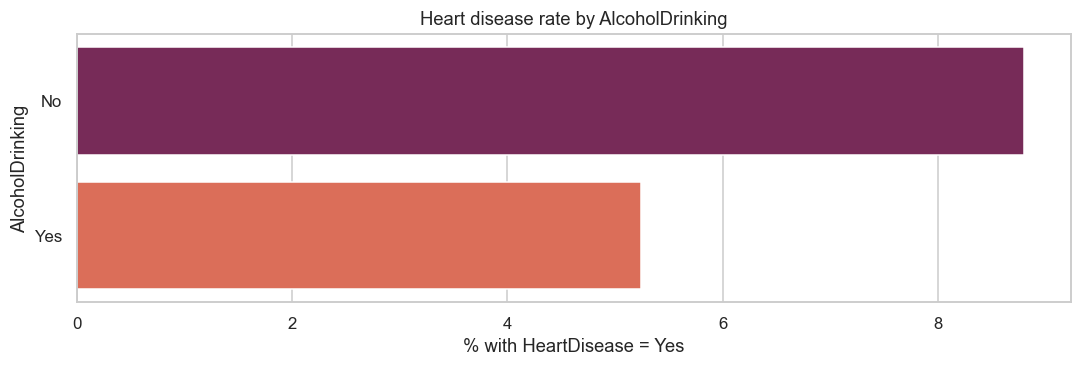

,Stroke,heart_disease_pct
1,Yes,36.37
0,No,7.47


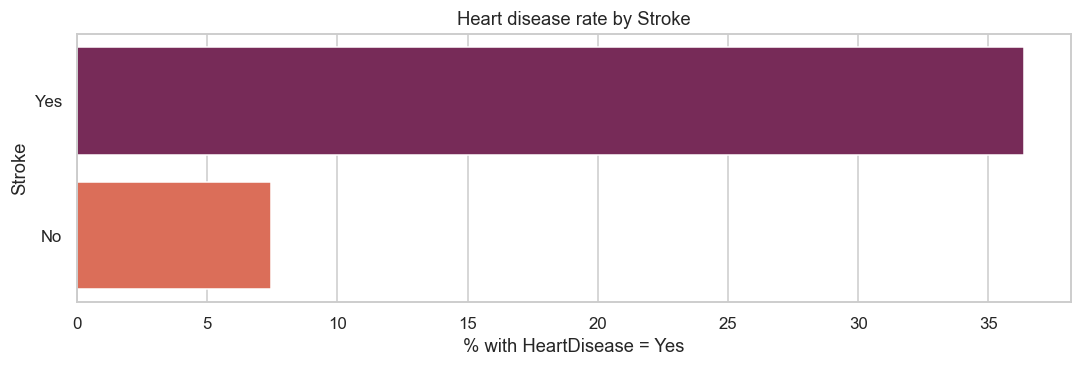

,DiffWalking,heart_disease_pct
1,Yes,22.58
0,No,6.30


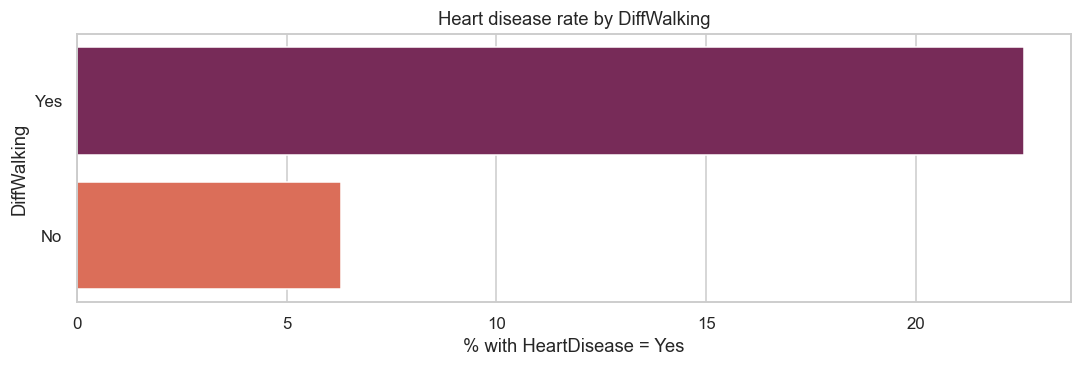

,Sex,heart_disease_pct
1,Male,10.62
0,Female,6.69


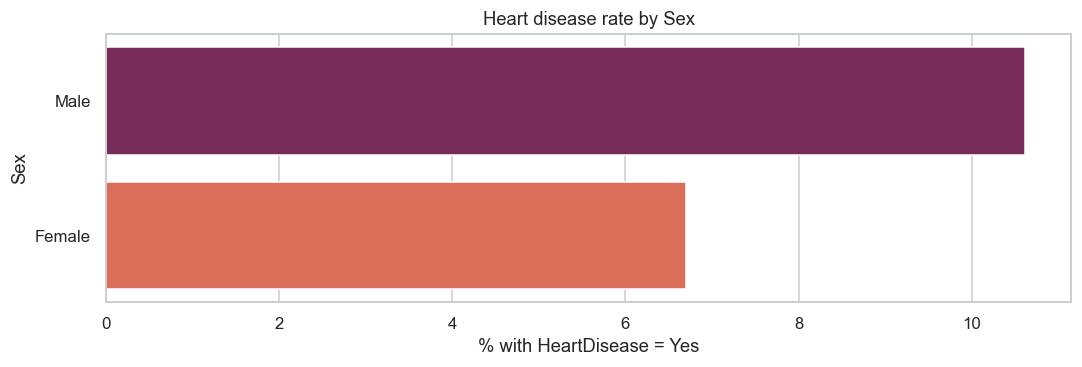

,AgeCategory,heart_disease_pct
12,80 or older,22.56
11,75-79,18.85
10,70-74,15.60
9,65-69,12.01
8,60-64,9.88
7,55-59,7.40
6,50-54,5.45
5,45-49,3.41
4,40-44,2.31
3,35-39,1.44


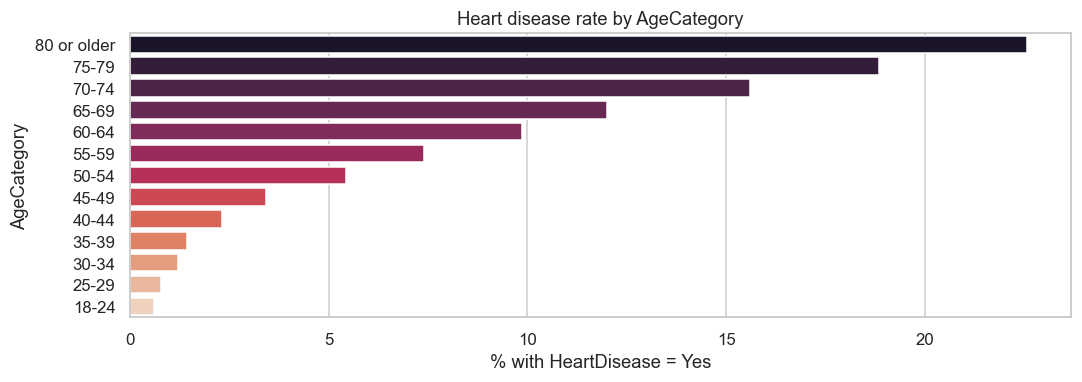

,Race,heart_disease_pct
0,American Indian/Alaskan Native,10.42
5,White,9.18
4,Other,8.11
2,Black,7.54
3,Hispanic,5.26
1,Asian,3.30


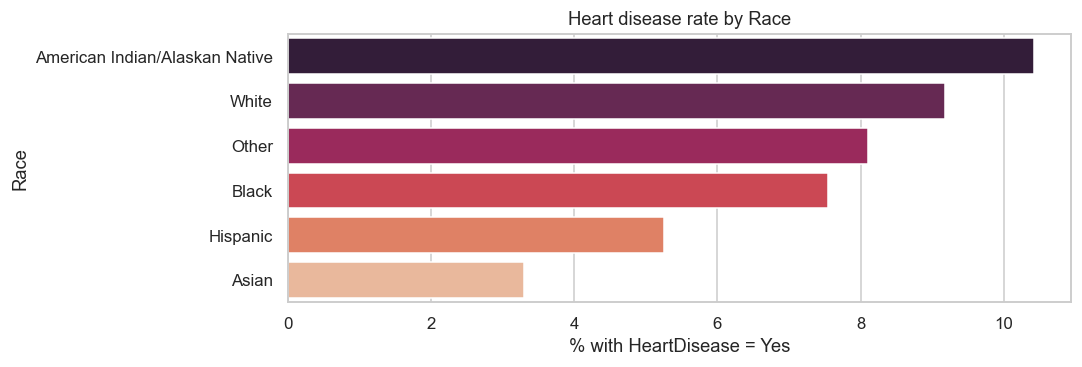

,Diabetic,heart_disease_pct
2,Yes,21.95
1,"No, borderline diabetes",11.64
0,No,6.50
3,Yes (during pregnancy),4.22


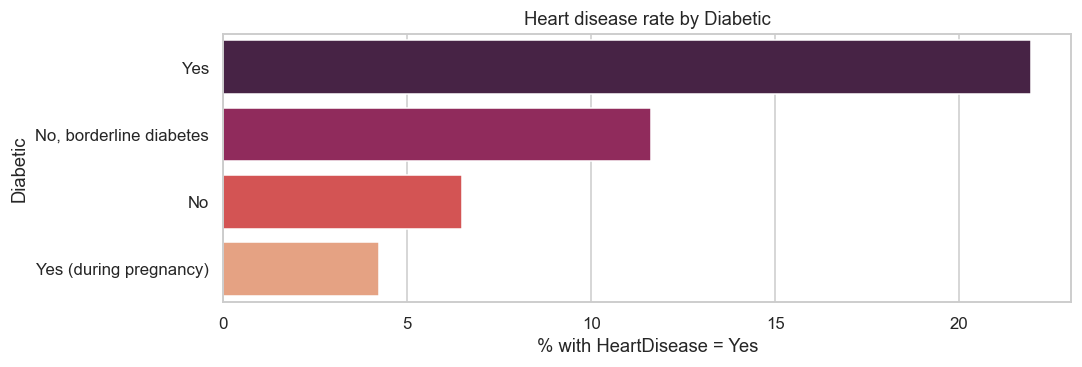

,PhysicalActivity,heart_disease_pct
0,No,13.76
1,Yes,7.05


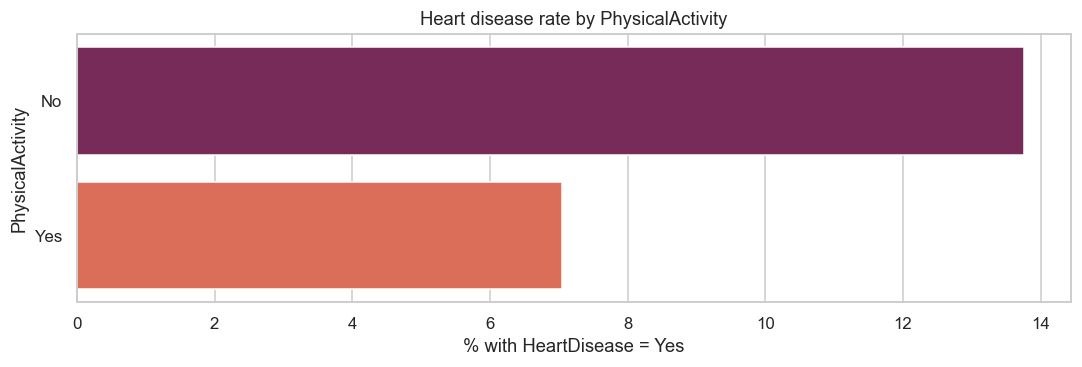

,GenHealth,heart_disease_pct
3,Poor,34.10
1,Fair,20.43
2,Good,10.26
4,Very good,4.73
0,Excellent,2.24


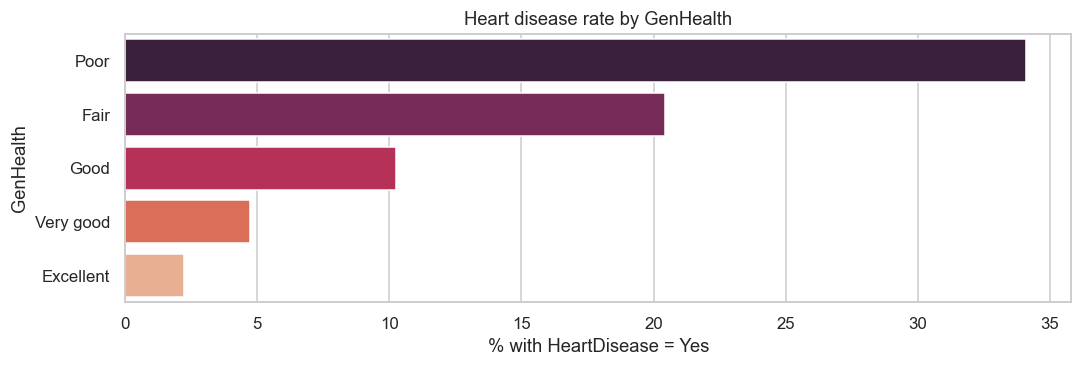

,Asthma,heart_disease_pct
1,Yes,11.51
0,No,8.10


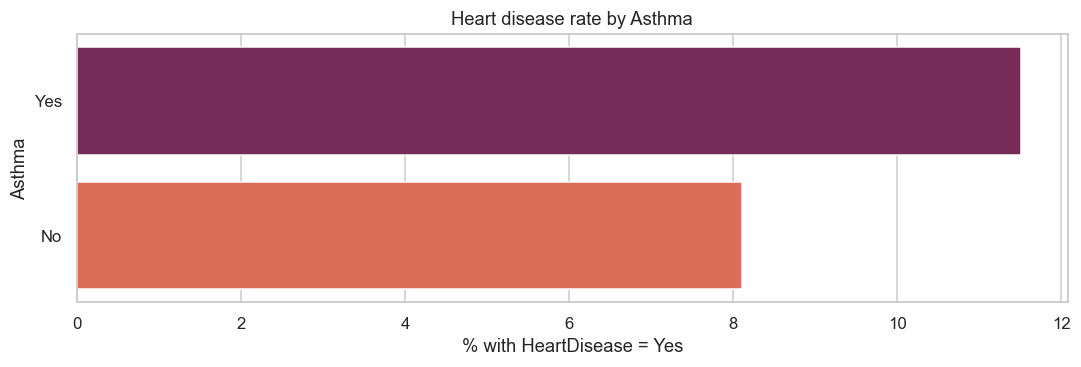

,KidneyDisease,heart_disease_pct
1,Yes,29.33
0,No,7.77


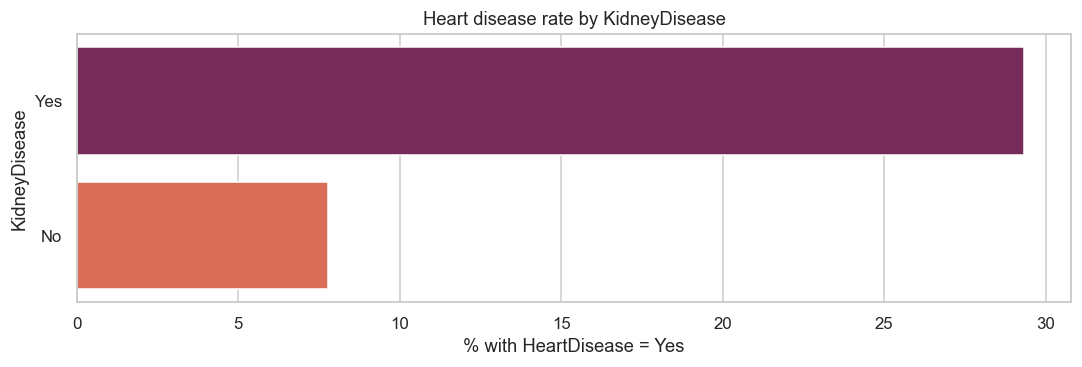

,SkinCancer,heart_disease_pct
1,Yes,16.70
0,No,7.72


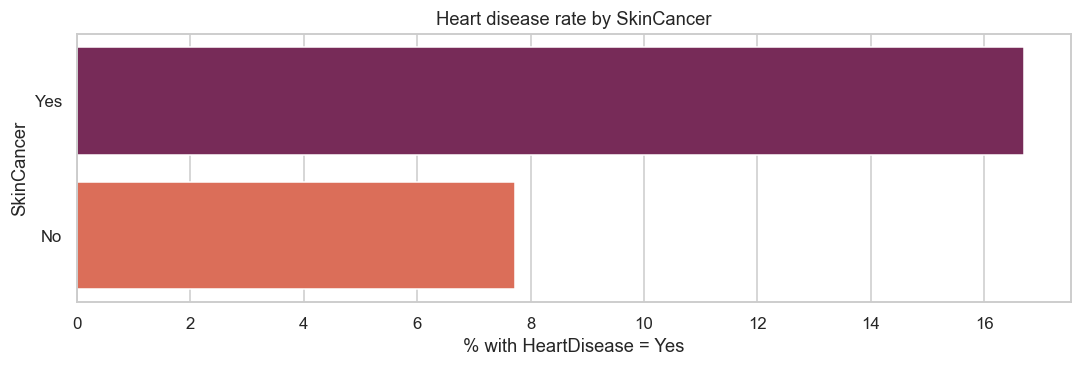

In [26]:
for col in cat_cols:
    ct = (
        df.groupby(col, dropna=False)["HeartDisease"]
        .apply(lambda s: (s == "Yes").mean() * 100)
        .reset_index(name="heart_disease_pct")
    )
    ct = ct.sort_values("heart_disease_pct", ascending=False)
    display(ct.style.format({"heart_disease_pct": "{:.2f}"}).set_caption(f"% HeartDisease=Yes by {col}"))

    plt.figure(figsize=(10, max(3.5, 0.28 * len(ct))))
    sns.barplot(data=ct, y=col, x="heart_disease_pct", palette="rocket")
    plt.xlabel("% with HeartDisease = Yes")
    plt.title(f"Heart disease rate by {col}")
    plt.tight_layout()
    plt.show()

## Stacked bar: distribution of `HeartDisease` within each category

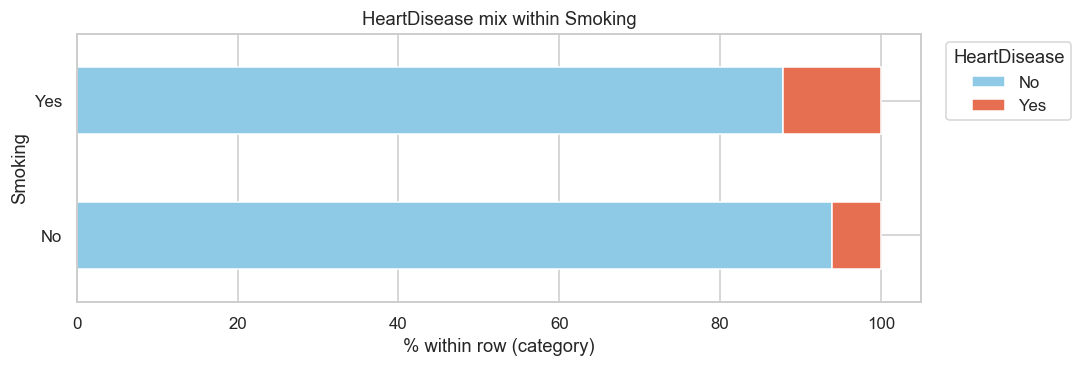

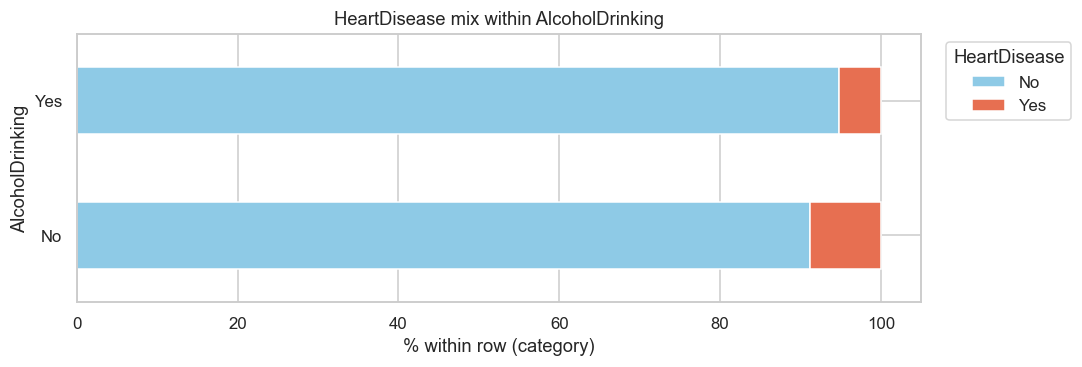

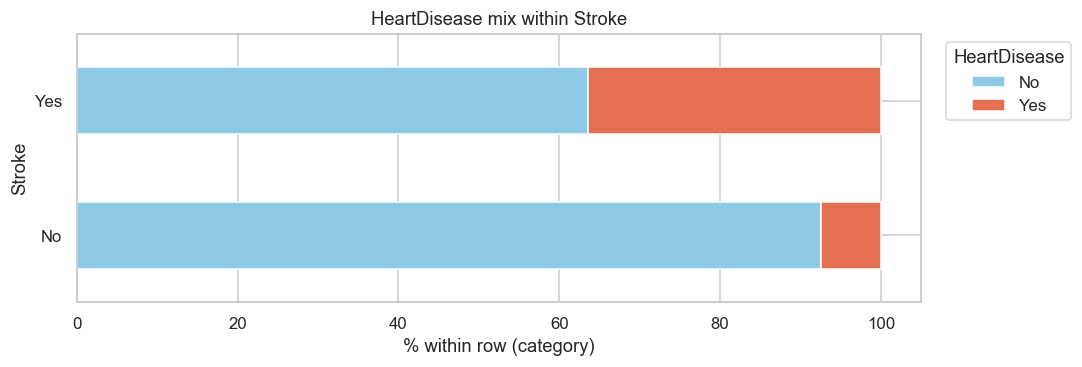

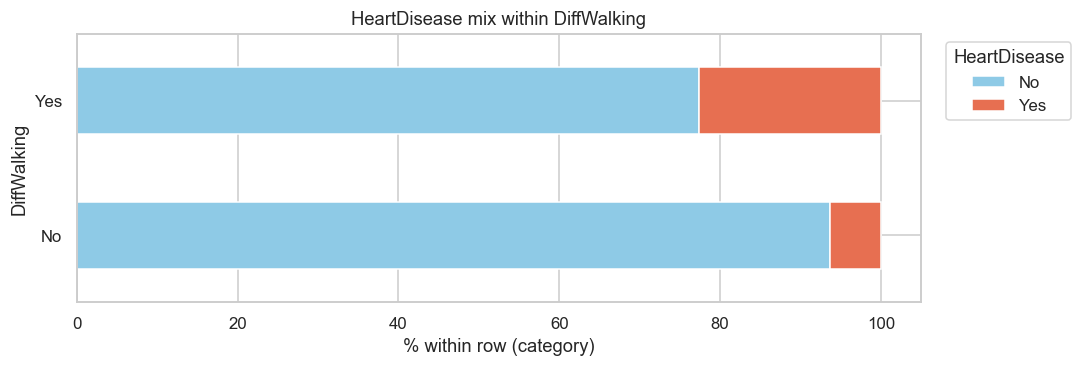

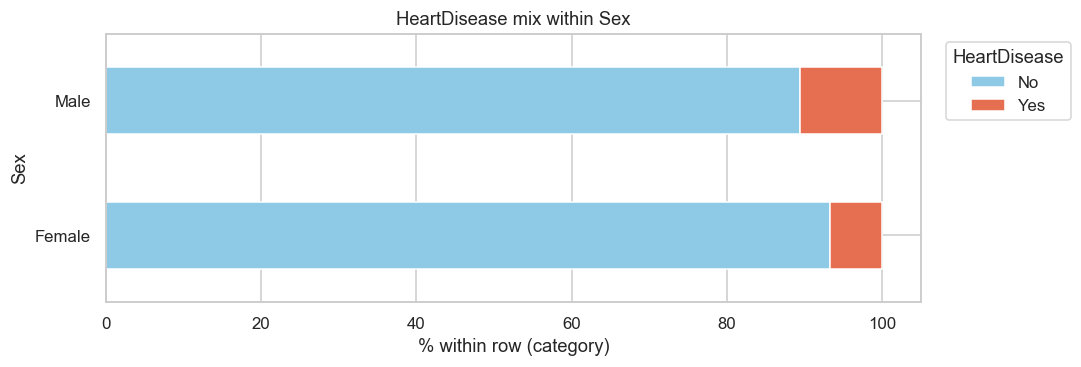

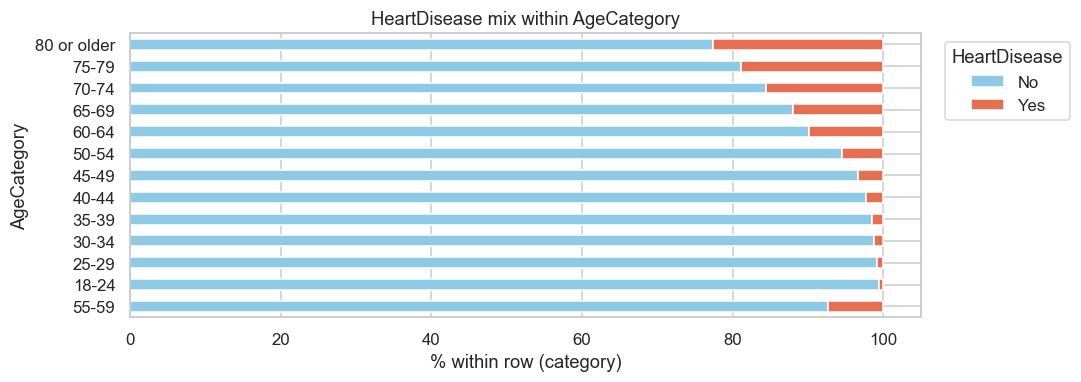

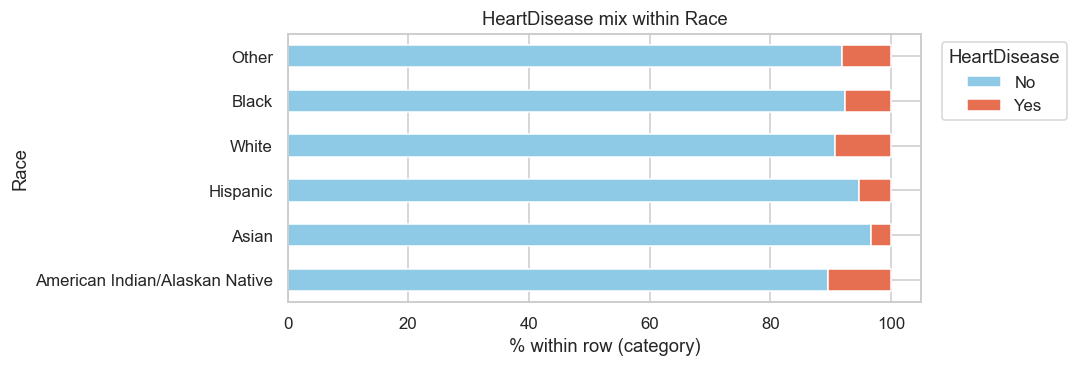

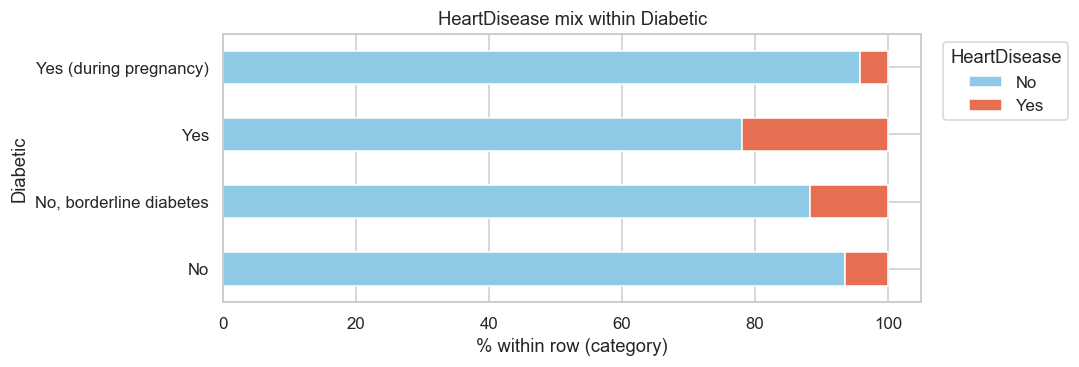

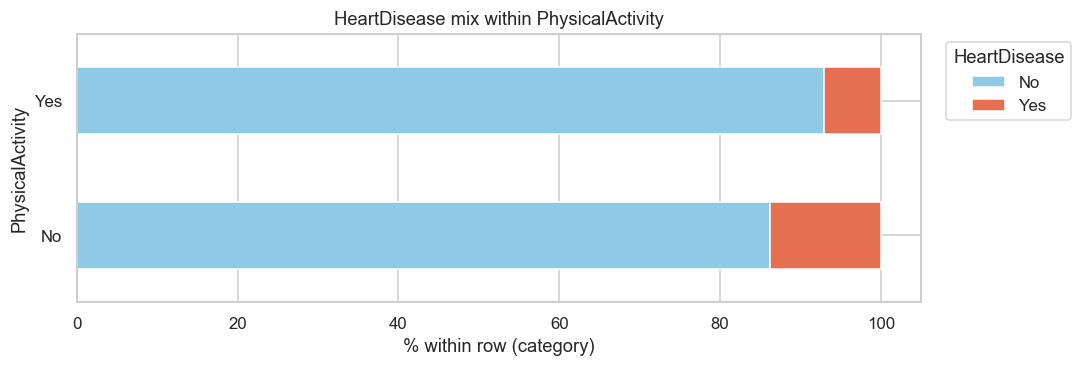

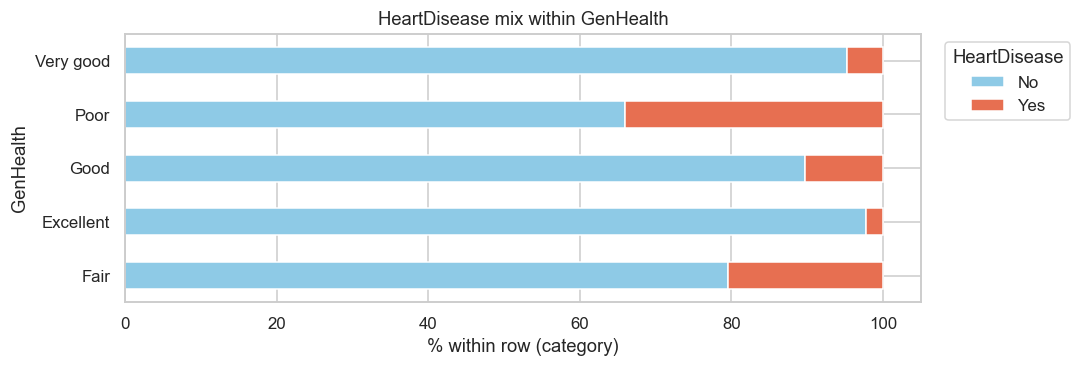

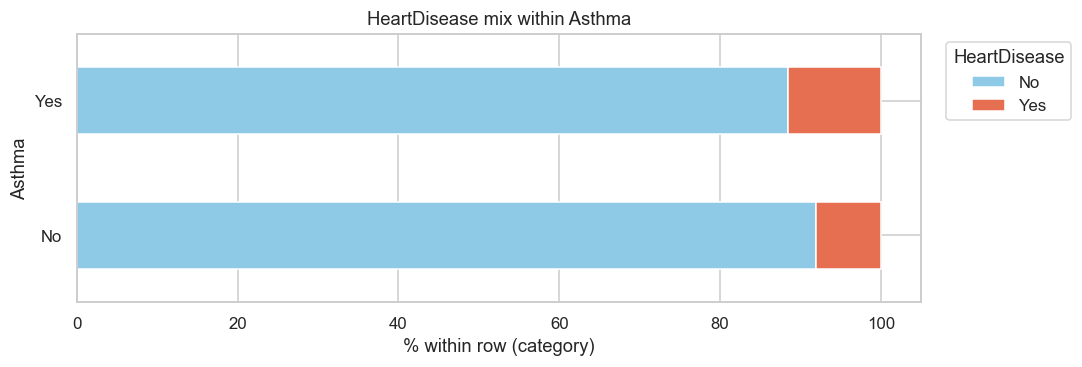

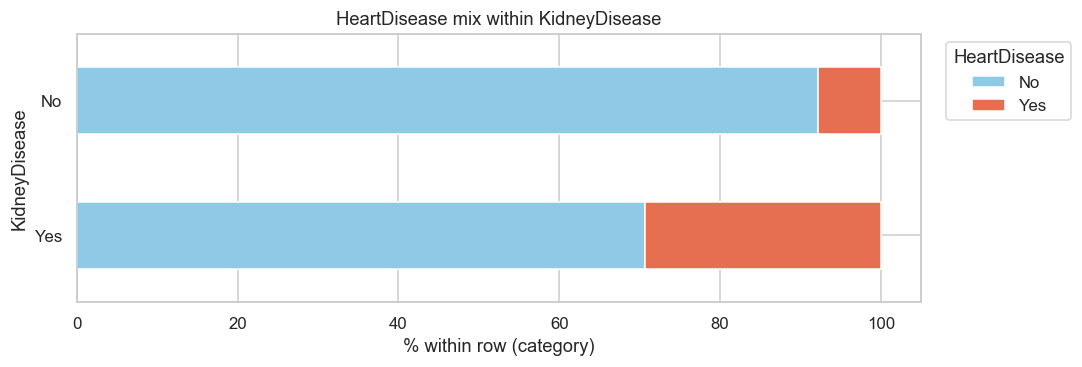

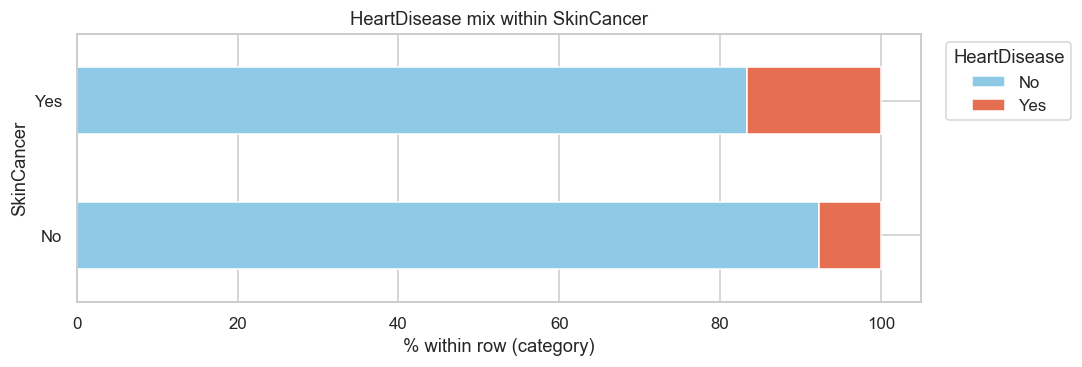

In [27]:
for col in cat_cols:
    ct = pd.crosstab(df[col], df["HeartDisease"], normalize="index") * 100
    ct = ct.reindex(ct.sum(axis=1).sort_values(ascending=False).index)
    ax = ct.plot(kind="barh", stacked=True, figsize=(10, max(3.5, 0.28 * len(ct))), color=["#8ecae6", "#e76f51"])
    ax.set_xlabel("% within row (category)")
    ax.set_title(f"HeartDisease mix within {col}")
    ax.legend(title="HeartDisease", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## `AgeCategory` — ordered prevalence of heart disease

,pct_heart_disease
AgeCategory,
18-24,0.62
25-29,0.78
30-34,1.21
35-39,1.44
40-44,2.31
45-49,3.41
50-54,5.45
55-59,7.40
60-64,9.88


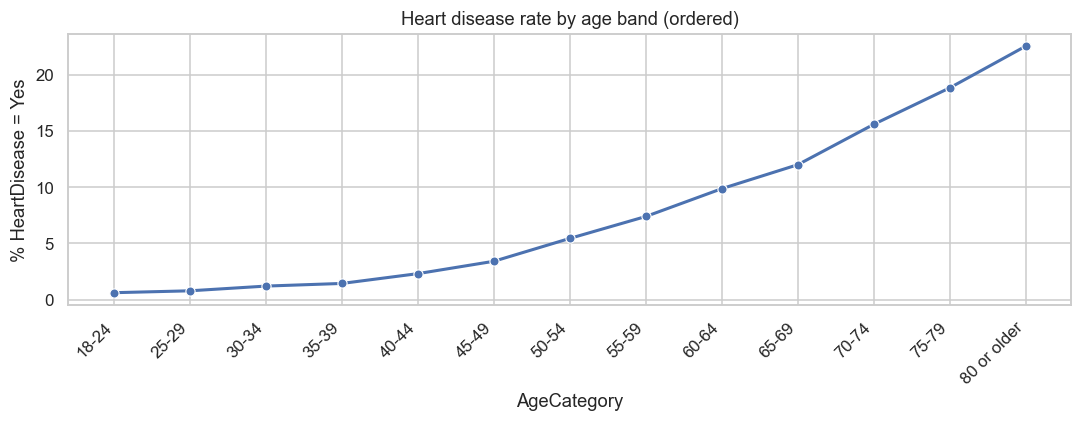

In [28]:
def age_cat_key(x):
    if pd.isna(x):
        return (999, x)
    s = str(x).replace(" or older", "+").strip()
    if "-" in s:
        lo = int(s.split("-")[0])
        return (lo, x)
    if s.endswith("+"):
        return (int(s.replace("+", "")), x)
    return (999, x)

age_order = sorted(df["AgeCategory"].dropna().unique(), key=age_cat_key)
age_rate = (
    df.groupby("AgeCategory")["HeartDisease"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .reindex(age_order)
)
display(age_rate.to_frame("pct_heart_disease").round(2))

plt.figure(figsize=(10, 4))
sns.lineplot(x=age_rate.index.astype(str), y=age_rate.values, marker="o", linewidth=2)
plt.xticks(rotation=45, ha="right")
plt.ylabel("% HeartDisease = Yes")
plt.title("Heart disease rate by age band (ordered)")
plt.tight_layout()
plt.show()

## BMI — distribution and WHO-style categories vs `HeartDisease`

,count
BMI_category,
Overweight (25–30),114512
Obese (30+),102842
Normal (18.5–25),97331
Underweight (<18.5),5110


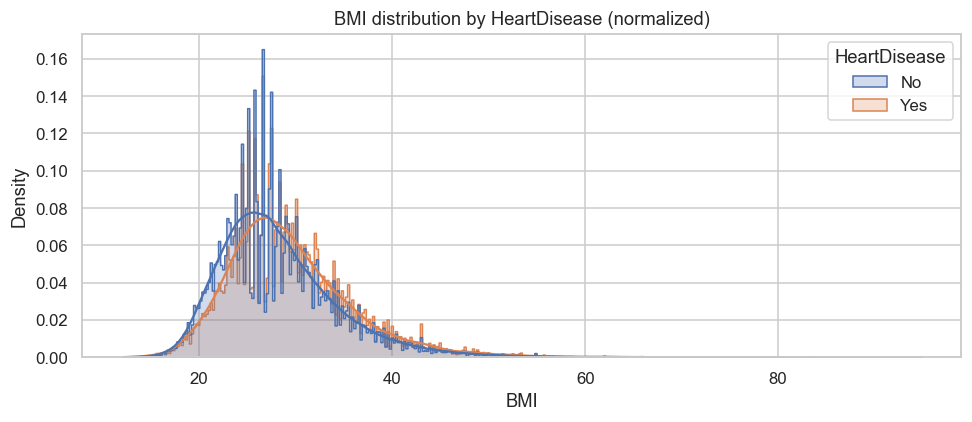

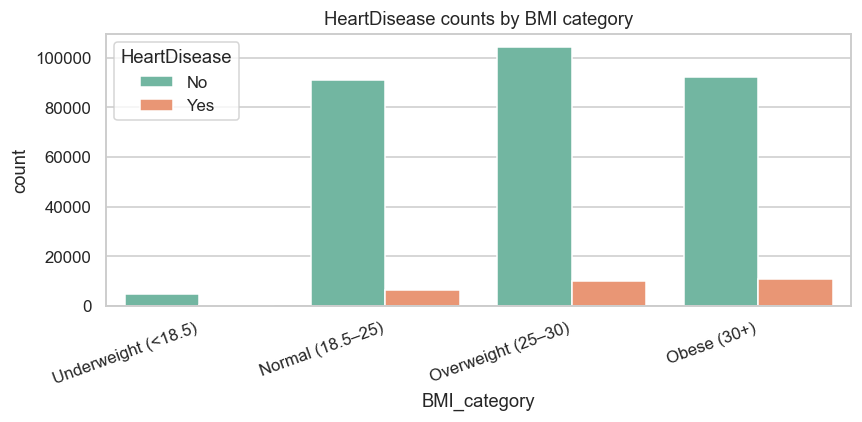

In [29]:
def bmi_bucket(b):
    if pd.isna(b):
        return np.nan
    if b < 18.5:
        return "Underweight (<18.5)"
    if b < 25:
        return "Normal (18.5–25)"
    if b < 30:
        return "Overweight (25–30)"
    return "Obese (30+)"

df["BMI_category"] = df["BMI"].map(bmi_bucket)
bmi_ct = df["BMI_category"].value_counts(dropna=False)
display(bmi_ct.to_frame("count"))

plt.figure(figsize=(9, 4))
sns.histplot(df, x="BMI", hue="HeartDisease", kde=True, element="step", stat="density", common_norm=False)
plt.title("BMI distribution by HeartDisease (normalized)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
order = ["Underweight (<18.5)", "Normal (18.5–25)", "Overweight (25–30)", "Obese (30+)"]
order = [o for o in order if o in df["BMI_category"].values]
sns.countplot(data=df, x="BMI_category", hue="HeartDisease", order=order, palette="Set2")
plt.xticks(rotation=20, ha="right")
plt.title("HeartDisease counts by BMI category")
plt.tight_layout()
plt.show()

## `GenHealth` ordered vs heart disease

HeartDisease,No,Yes
GenHealth,,
Excellent,97.76,2.24
Very good,95.27,4.73
Good,89.74,10.26
Fair,79.57,20.43
Poor,65.90,34.10


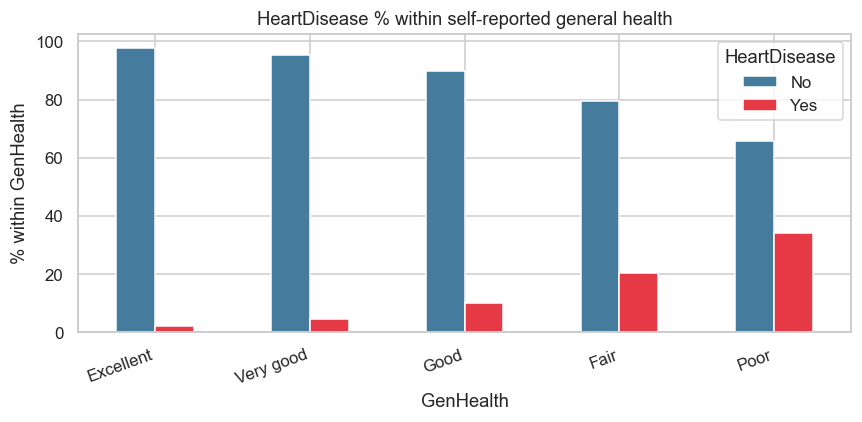

In [30]:
gh_order = ["Excellent", "Very good", "Good", "Fair", "Poor"]
gh_order = [g for g in gh_order if g in df["GenHealth"].values]
ct = pd.crosstab(df["GenHealth"], df["HeartDisease"], normalize="index") * 100
ct = ct.reindex(gh_order)
display(ct.round(2))
ct.plot(kind="bar", figsize=(8, 4), color=["#457b9d", "#e63946"])
plt.ylabel("% within GenHealth")
plt.title("HeartDisease % within self-reported general health")
plt.xticks(rotation=20, ha="right")
plt.legend(title="HeartDisease")
plt.tight_layout()
plt.show()

## `SleepTime` — distribution and rates

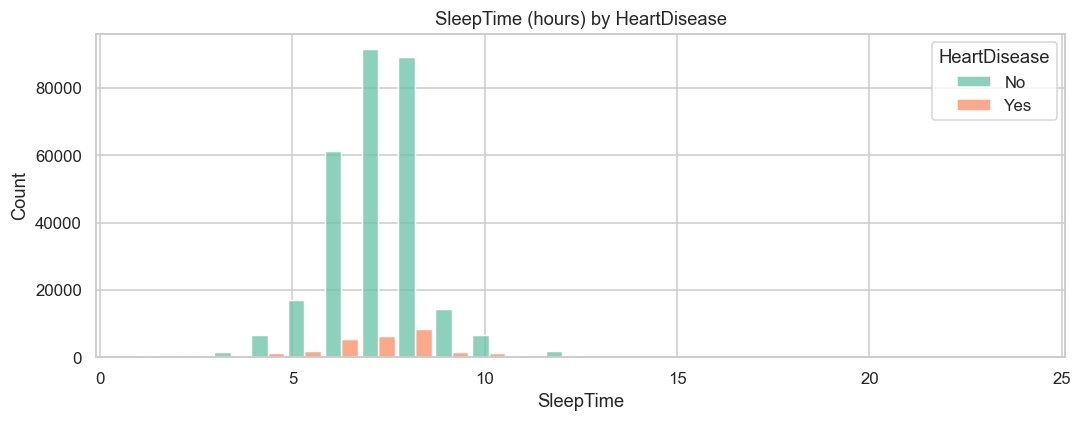

,SleepTime,pct
0,1,10.889292
1,2,16.243655
2,3,17.419679
3,4,15.225806
4,5,10.581735
5,6,8.133871
6,7,6.470522
7,8,8.563349
8,9,10.572907
9,10,14.943561


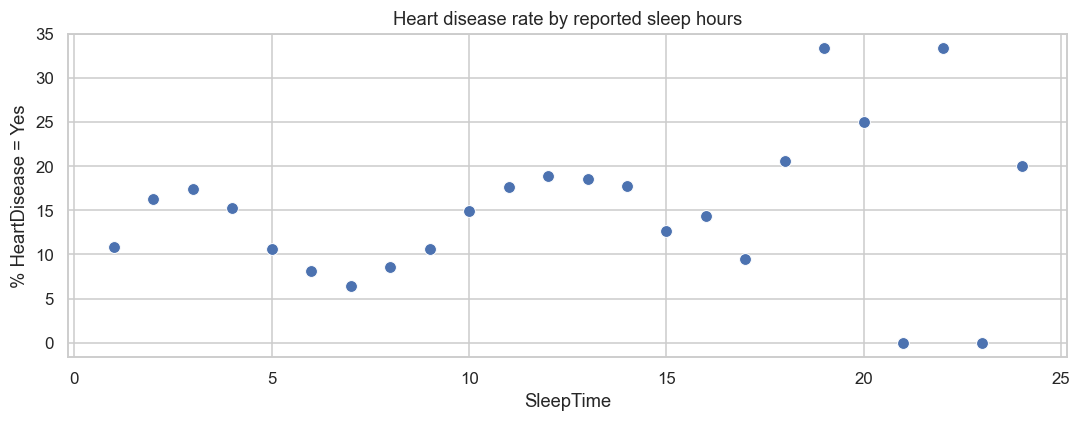

In [31]:
plt.figure(figsize=(10, 4))
sns.histplot(df, x="SleepTime", hue="HeartDisease", multiple="dodge", bins=24, shrink=0.9, palette="Set2")
plt.title("SleepTime (hours) by HeartDisease")
plt.tight_layout()
plt.show()

sleep_rate = (
    df.groupby("SleepTime")["HeartDisease"].apply(lambda s: (s == "Yes").mean() * 100).reset_index(name="pct")
)
display(sleep_rate.sort_values("SleepTime").head(30))
plt.figure(figsize=(10, 4))
sns.scatterplot(data=sleep_rate, x="SleepTime", y="pct", s=60)
plt.ylabel("% HeartDisease = Yes")
plt.title("Heart disease rate by reported sleep hours")
plt.tight_layout()
plt.show()

## `Race` — counts and crosstab with `HeartDisease`

HeartDisease,No,Yes,All
Race,,,
American Indian/Alaskan Native,4660,542,5202
Asian,7802,266,8068
Black,21210,1729,22939
Hispanic,26003,1443,27446
Other,10042,886,10928
White,222705,22507,245212
All,292422,27373,319795


HeartDisease,No,Yes
Race,,
American Indian/Alaskan Native,89.58,10.42
Asian,96.70,3.30
Black,92.46,7.54
Hispanic,94.74,5.26
Other,91.89,8.11
White,90.82,9.18


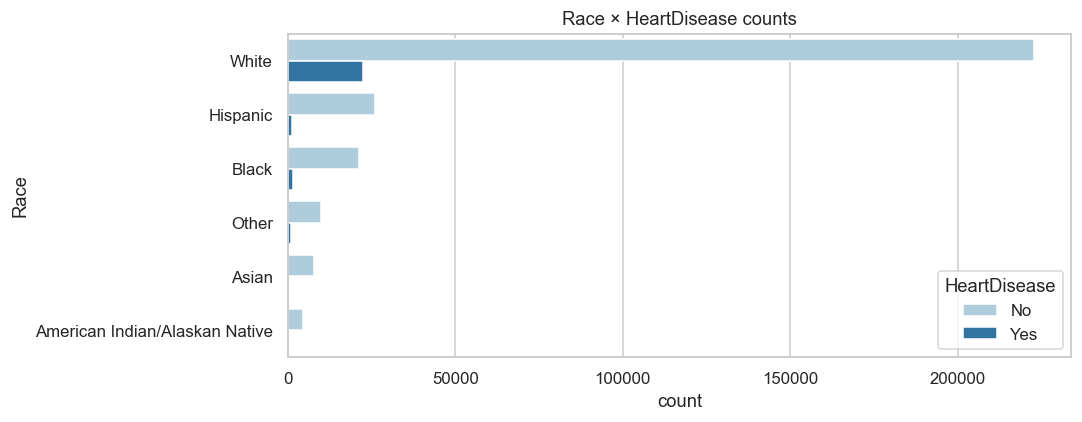

In [32]:
display(pd.crosstab(df["Race"], df["HeartDisease"], margins=True))
display(pd.crosstab(df["Race"], df["HeartDisease"], normalize="index").mul(100).round(2))
plt.figure(figsize=(10, 4))
race_order = df["Race"].value_counts().index
sns.countplot(data=df, y="Race", hue="HeartDisease", order=race_order, palette="Paired")
plt.title("Race × HeartDisease counts")
plt.tight_layout()
plt.show()

## `Diabetic` — detailed crosstabs

HeartDisease,No,Yes,All
Diabetic,,,
No,252134,17519,269653
"No, borderline diabetes",5992,789,6781
Yes,31845,8957,40802
Yes (during pregnancy),2451,108,2559
All,292422,27373,319795


HeartDisease,No,Yes
Diabetic,,
No,93.50,6.50
"No, borderline diabetes",88.36,11.64
Yes,78.05,21.95
Yes (during pregnancy),95.78,4.22


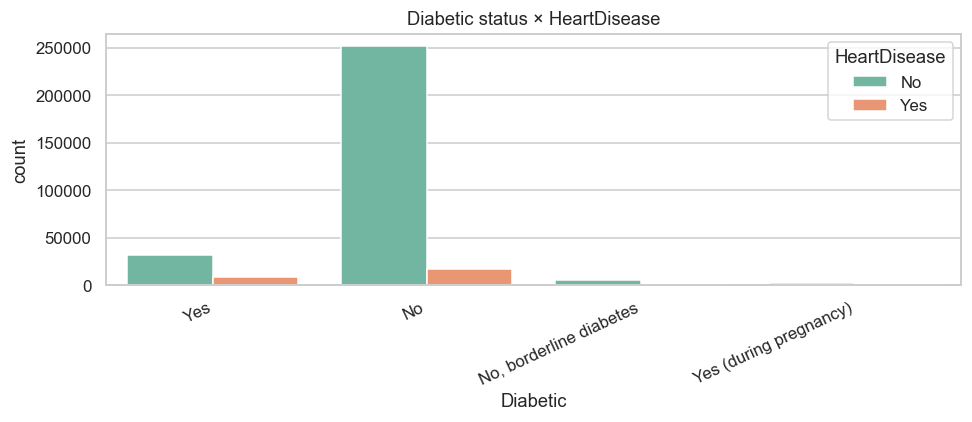

In [33]:
display(pd.crosstab(df["Diabetic"], df["HeartDisease"], margins=True))
display(pd.crosstab(df["Diabetic"], df["HeartDisease"], normalize="index").mul(100).round(2))
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x="Diabetic", hue="HeartDisease", palette="Set2")
plt.xticks(rotation=25, ha="right")
plt.title("Diabetic status × HeartDisease")
plt.tight_layout()
plt.show()

## `Sex` — counts and rates

HeartDisease,No,Yes,All
Sex,,,
Female,156571,11234,167805
Male,135851,16139,151990
All,292422,27373,319795


HeartDisease,No,Yes
Sex,,
Female,93.31,6.69
Male,89.38,10.62


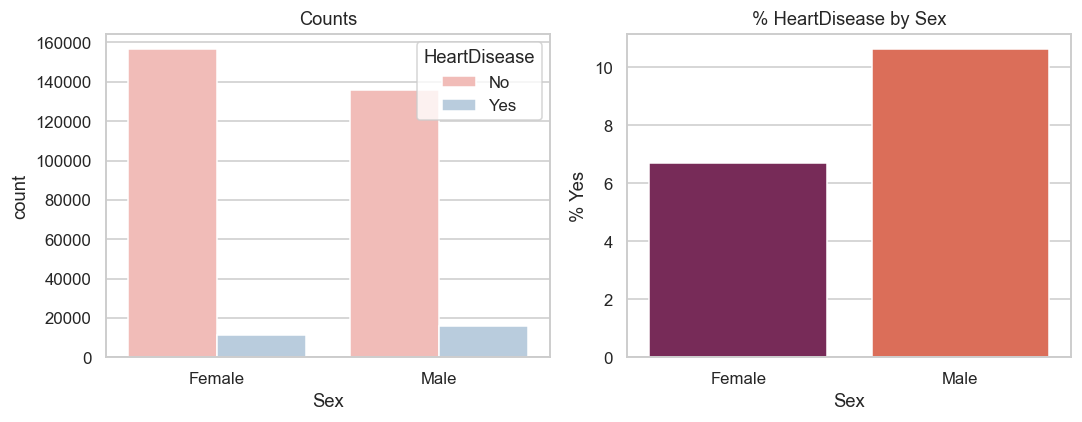

In [34]:
display(pd.crosstab(df["Sex"], df["HeartDisease"], margins=True))
display(pd.crosstab(df["Sex"], df["HeartDisease"], normalize="index").mul(100).round(2))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x="Sex", hue="HeartDisease", ax=axes[0], palette="Pastel1")
axes[0].set_title("Counts")
rate = df.groupby("Sex")["HeartDisease"].apply(lambda s: (s == "Yes").mean() * 100)
sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[1], palette="rocket")
axes[1].set_ylabel("% Yes")
axes[1].set_title("% HeartDisease by Sex")
plt.tight_layout()
plt.show()

## Physical vs mental health — joint view

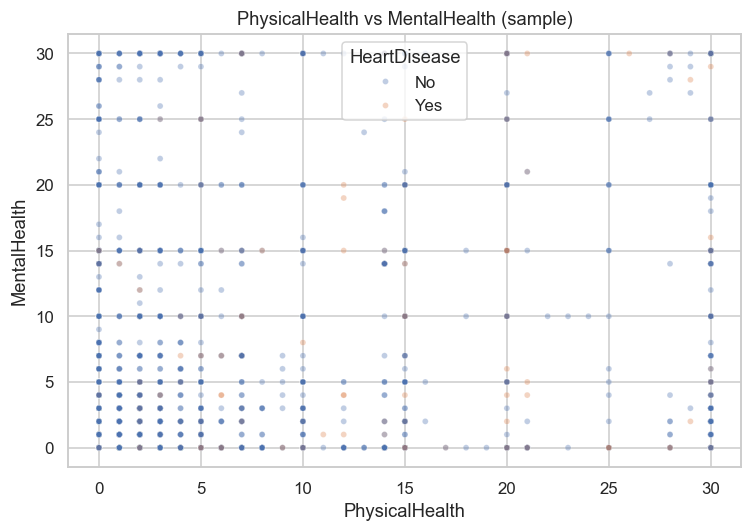

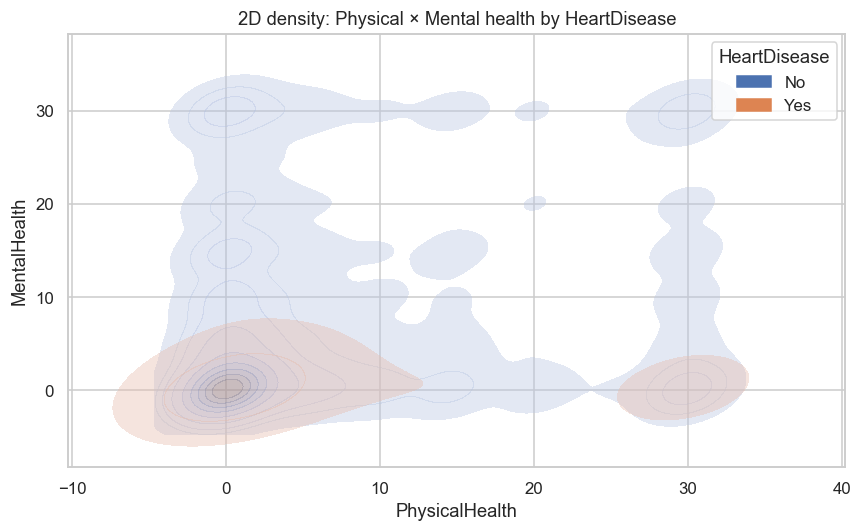

In [35]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df.sample(min(8000, len(df)), random_state=RANDOM_STATE),
    x="PhysicalHealth",
    y="MentalHealth",
    hue="HeartDisease",
    alpha=0.35,
    s=15,
)
plt.title("PhysicalHealth vs MentalHealth (sample)")
plt.tight_layout()
plt.show()

kde_n = min(15000, len(df))
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df.sample(kde_n, random_state=RANDOM_STATE),
    x="PhysicalHealth",
    y="MentalHealth",
    hue="HeartDisease",
    fill=True,
    alpha=0.4,
    thresh=0.05,
)
plt.title("2D density: Physical × Mental health by HeartDisease")
plt.tight_layout()
plt.show()

## Encoded correlation heatmap (all features, approximate)

Label-encoded categoricals + numeric columns — useful for a single global association view (interpret with care).

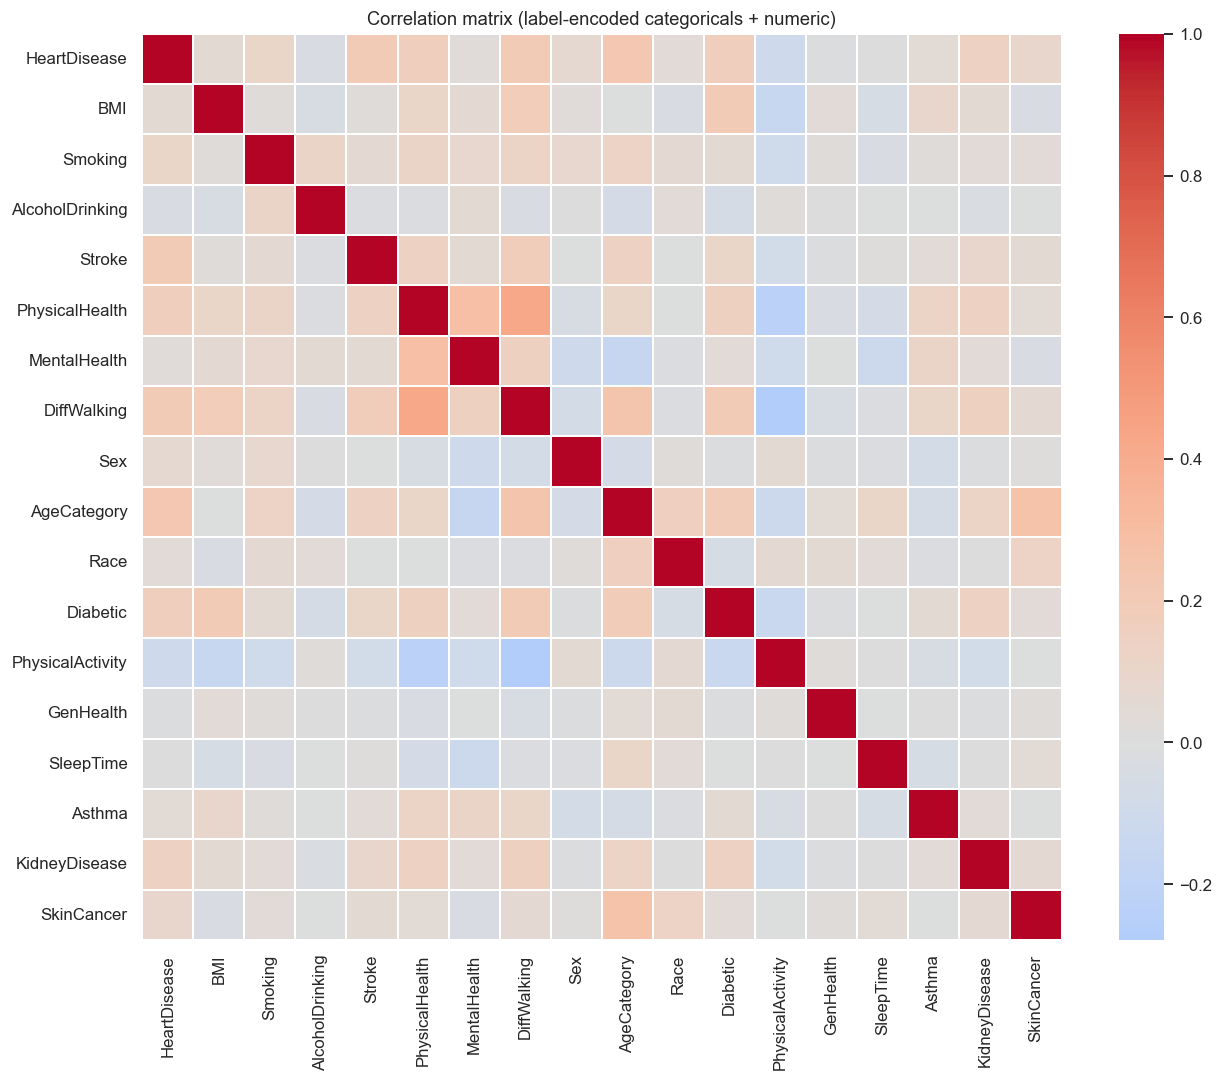

,corr_with_HeartDisease
AgeCategory,0.2334
DiffWalking,0.2013
Stroke,0.1968
PhysicalHealth,0.1707
Diabetic,0.1686
KidneyDisease,0.1452
Smoking,0.1078
PhysicalActivity,-0.1000
SkinCancer,0.0933
Sex,0.0700


In [36]:
df_enc = df.drop(columns=["BMI_category"], errors="ignore").copy()
for c in df_enc.columns:
    if df_enc[c].dtype == object:
        df_enc[c] = pd.Categorical(df_enc[c]).codes
corr_all = df_enc.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_all, annot=False, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation matrix (label-encoded categoricals + numeric)")
plt.tight_layout()
plt.show()
hd_corr = corr_all["HeartDisease"].drop("HeartDisease").sort_values(key=abs, ascending=False)
display(hd_corr.to_frame("corr_with_HeartDisease").round(4))

## Summary snapshot table

In [37]:
summary = pd.DataFrame({
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "numeric_features": [len(num_cols)],
    "categorical_features": [len(cat_cols)],
    "missing_cells": [int(df.isna().sum().sum())],
    "duplicate_rows": [int(df.duplicated().sum())],
    "heart_disease_yes_pct": [round((df["HeartDisease"] == "Yes").mean() * 100, 3)],
})
display(summary.T.rename(columns={0: "value"}))

,value
rows,319795.00
columns,19.00
numeric_features,4.00
categorical_features,13.00
missing_cells,0.00
duplicate_rows,18078.00
heart_disease_yes_pct,8.56
